# Experiment E01 — Main Evaluation Sweep: Federated Gain, R-D Curves, Summary Tables and Statistics

> **Experiment Specification / Experiment Contract**
>
> This cell is a formal contract describing the entire experiment. It is
> intended to be read by future AI agents that will write the corresponding
> sections of the LaTeX research paper.

## Experiment Identity

- **Experiment ID:** `E01`
- **Experiment title:** Main evaluation sweep — federated gain, R-D curves, summary tables and statistics
- **Scientific purpose:** Headline quantitative evaluation of F-SIBS as a federated
  image-reconstruction method. Sweeps every selected method over a fixed sparsity
  grid `K_SWEEP`, builds rate-distortion curves, summary tables at
  `k = K_SUMMARY = 8`, and paired per-node statistical comparisons between every
  F-SIBS variant and every baseline.
- **Relationship to the overall paper:** This is the *headline federated
  quality-enhancement* experiment of the paper.
- **Notebook source:** `E01_main_sweep_federated_gain.ipynb`.
- **Run folder:** `F_SIBS_r_<date>_<n>/` (shared with E00/E02/E03).
- **Outputs (this enhanced notebook):**
  - `RUN_DIR/figures/exp01_rd_curves_ssim.png`
  - `RUN_DIR/figures/exp01_rd_curves_psnr.png`
  - `RUN_DIR/figures/exp01_bar_comparison_ssim.png`
  - `RUN_DIR/figures/exp01_bar_comparison_psnr.png`
  - `RUN_DIR/figures/exp01_reconstruction_gallery.png`
  - `RUN_DIR/figures/exp01_paired_gain_beeswarm.png`
  - `RUN_DIR/figures/exp01_ssim_ecdf.png`
  - `RUN_DIR/figures/exp01_gain_vs_difficulty.png`
  - `RUN_DIR/Exp01_Results.tex` (consolidated LaTeX results file)

## Scientific Objective

- **Objective:** Quantitatively demonstrate that the federated F-SIBS variants
  outperform (i) their underlying local SIBS counterparts (paired comparison,
  same k); (ii) independent OMP at equal k; (iii) reference distributed codecs
  (LDMIC-equiv, NDIC-equiv, NDIC-real); (iv) traditional still-image codecs
  (BPG-equiv/JPEG2000, JPEG, JPEG-LS, SPIHT, CALIC) at BPP-matched operating
  points.
- **Research question(s):**
  1. Does F-SIBS_i achieve higher SSIM/PSNR than its underlying local SIBS_i
     at equal sparsity, on every selected dataset?
  2. Is the per-node SSIM gain from federation statistically significant
     after multiple-comparison correction?
  3. How does F-SIBS trade off against traditional codecs on the
     rate-distortion plane?
- **Hypothesis:** Federation improves mean SSIM at equal k, with a positive
  effect size (Cohen's d_z > 0) that remains significant after Holm-Bonferroni
  and Benjamini-Hochberg correction within each dataset family.

## Data

- **Dataset / data source:** `coil20`, `dino`, `temple` (default selection).
- **Dataset characteristics:** grey-scale 8-bit; `coil20` 128×128 px, 80 nodes;
  `dino` 96×128 px, 16 nodes; `temple` 96×128 px, 16 nodes.
- **Preprocessing:** same as E00.
- **Number of samples:** 112 nodes total (default selection).

## Methods

- **Proposed methods:** `F-SIBS_1..4`.
- **Baselines:** `OMP`, `SIBS1..4`.
- **Reference methods:** `NDIC-equiv s=4/8`, `NDIC-real`, `LDMIC-equiv`,
  `BPG-equiv (JPEG2000)`, `JPEG`, `JPEG-LS`, `SPIHT`, `CALIC`.
- **Method configurations:** sparse-coding methods swept over `K_SWEEP`;
  federated variants use `K_global = K_GLOBAL`, `n_rounds = N_ROUNDS_SWEEP`,
  `tau = 0.95`, `eps_conv = EPS_CONV`, `seed = RNG_SEED`. Codec methods are
  rate-swept; their BPP-matched summary row is the rate whose BPP is closest
  to the sparse BPP at `k = K_SUMMARY`.

## Experimental Design

- **Independent variables:** dataset, method, sparsity k (sparse methods) or
  rate (codec methods), federated group configuration.
- **Dependent variables:** SSIM, PSNR (dB), NMSE, BPP.
- **Controlled variables:** dictionary Φ, federated hyper-parameters, RNG_SEED,
  DELTA, image geometry.
- **Parameters:** `K_SWEEP`, `K_SUMMARY = 8`, `K_GLOBAL`, `N_ROUNDS_SWEEP`,
  `EPS_CONV`, `DELTA` — from `fsibs.protocol`.
- **Number of trials:** one trial per (method, node, k) triple; federated runs
  are single-trial with `seed = RNG_SEED`.

## Evaluation

- **Metrics:** SSIM, PSNR (dB), NMSE, BPP, dictionary coherence μ.
- **Mathematical definitions:** SSIM, PSNR, NMSE, BPP as in E00; paired
  t-tests via `scipy.stats.ttest_rel` (per-node pairs); Holm-Bonferroni and
  Benjamini-Hochberg corrections within each dataset family; Cohen's d_z
  (paired) and Hedges' g_z effect sizes.
- **Statistical analysis:** Paired t-tests (F-SIBS variants vs. every baseline),
  with Holm-Bonferroni and Benjamini-Hochberg adjusted p-values within each
  dataset family, plus Cohen's d_z / Hedges' g_z effect sizes. Significance
  thresholds: `ALPHA = 0.05`, `ALPHA_STRICT = 0.01`.

## Outputs

- **Raw experimental results:** `RESULTS` (DataFrame, ~13k rows for default
  selection). Cached to `fsibs_full_results_v2__<fingerprint>.csv` (the
  fingerprint embeds the active selection so a stale cache from a different
  configuration can never be silently mixed in).
- **Processed results:** `SUMMARY` (DataFrame at k = K_SUMMARY); `STAT_DF`
  (paired t-tests + adjusted p-values + effect sizes); `GAIN_DF`
  (per-node delta-SSIM).
- **Figures (PNG @ 300 DPI, shared `figures/` folder):**
  - `exp01_rd_curves_ssim.png`, `exp01_rd_curves_psnr.png`
  - `exp01_bar_comparison_ssim.png`, `exp01_bar_comparison_psnr.png`
  - `exp01_reconstruction_gallery.png`
  - `exp01_paired_gain_beeswarm.png`
  - `exp01_ssim_ecdf.png`
  - `exp01_gain_vs_difficulty.png`
- **Tables:** `SUMMARY`, `STAT_DF` (with `p_adj_holm`, `p_adj_bh`,
  `cohens_d_z`, `hedges_g_z` columns from the V3.2 additions).
- **Consolidated LaTeX:** `RUN_DIR/Exp01_Results.tex`.

## Reproducibility

- **Software environment:** Python 3.12.12 (Jupyter Enterprise Gateway kernel
  `jupyter-eg-kernel-slurm-py312-1jo1fcc3c`). Captured at run time.
- **Hardware:** Linux x86_64, 96 CPU cores, multiprocessing available.
- **Random seeds:** `RNG_SEED` (global, `fsibs.protocol.RNG_SEED`).
- **Execution configuration:** `RUN_DIR_POLICY = "latest"`;
  `INTERACTIVE_SELECTION = False`; default selection
  `["coil20", "dino", "temple"]` with all 18 algorithms selected;
  `FORCE_RECOMPUTE = False`; `USE_PARALLEL_SWEEP = True`.
- **Parallelization:** `fsibs.main_sweep.load_or_run_main_sweep` with
  `use_parallel=True` dispatches Parts A/B/C through a ProcessPoolExecutor
  when safe, else falls back to the serial tqdm loop.
- **`[REQUIRES CONFIRMATION]` items:**
  - `fsibs.protocol.K_SWEEP` (sparsity grid; imported but not displayed).
  - `fsibs.protocol.RNG_SEED` (exact integer value).
  - The cache fingerprint algorithm is internal to `fsibs.main_sweep`; the
    printed fingerprint string is recorded in run-time stdout.


# E01 -- Main evaluation sweep: federated gain, R-D curves, summary tables and statistics

Runs (or loads from cache) the main sweep over all selected datasets and methods (single-image sparse coders, codecs, F-SIBS variants, LDMIC/NDIC baselines), then builds the summary tables at k = K_SUMMARY, rate-distortion plots and the paired-significance analysis.

* **Independent:** run this notebook top-to-bottom in a fresh kernel; it needs no other notebook's in-memory state.
* **Needs:** datasets; the sweep engine `fsibs.main_sweep` (its cache is shared with E03 when the sweep settings match).
* **Writes:** `fsibs_full_results_v2__<fingerprint>.csv`, summary tables/figures, `stat_main_sweep.csv`, `results/experiment_1/`.
* **Shared code:** imported from the `fsibs` package (see `README.md`); everything experiment-specific is in this notebook.

In [1]:
# ============================================================
# F-SIBS MODULAR - PROJECT LOCATION + IMPORTS
# ============================================================

import sys,time, os
from pathlib import Path

# ------------------------------------------------------------
# Project location
# ------------------------------------------------------------

PROJECT_ROOT = Path("/home/ahmed_omara/F_SIBS_Modular").resolve()
PACKAGE_ROOT = PROJECT_ROOT / "fsibs"

# Validate project
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"\nF-SIBS project directory was not found:\n"
        f"  {PROJECT_ROOT}"
    )

if not PACKAGE_ROOT.exists():
    raise FileNotFoundError(
        f"\nF-SIBS package directory was not found:\n"
        f"  {PACKAGE_ROOT}\n\n"
        f"Project contents:\n"
        + "\n".join(f"  {p.name}" for p in PROJECT_ROOT.iterdir())
    )

if not (PACKAGE_ROOT / "__init__.py").exists():
    raise FileNotFoundError(
        f"\nF-SIBS package was found, but __init__.py is missing:\n"
        f"  {PACKAGE_ROOT / '__init__.py'}"
    )

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Use the project root as the working directory
import os
os.chdir(PROJECT_ROOT)

# ------------------------------------------------------------
# Standard imports
# ------------------------------------------------------------

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# F-SIBS imports
# ------------------------------------------------------------

from fsibs.codecs import (
    TRADITIONAL_CODEC_FNS,
    jpeg2000_encode_decode,
    run_bpg_equiv,
    run_traditional_codec,
)

from fsibs.datasets import build_data_bundle

from fsibs.env import setup_environment

from fsibs.federated import (
    F_SIBS_VARIANT_TO_SIBS,
    ldmic_equiv_simulate,
    ndic_equiv,
)

from fsibs.io_utils import save_figure

from fsibs.main_sweep import load_or_run_main_sweep

from fsibs.metrics import (
    bpp_sparse,
    ssim,
)

from fsibs.parallel import (
    PBAR_FORMAT,
    describe,
)

from fsibs.runtime import (
    init_run,
    new_manifest,
    save_manifest,
)

from fsibs.selection import (
    AVAILABLE_F_SIBS_VARIANTS,
    AVAILABLE_SIBS_VARIANTS,
    prompt_selection,
    resolve_selection,
)

from fsibs.sparse_coding import omp_baseline

from fsibs.stats import (
    HAS_SCIPY,
    benjamini_hochberg,
    holm_bonferroni,
    significance_marker,
    stats,
)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------

print("=" * 70)
print("F-SIBS MODULAR PROJECT")
print("=" * 70)
print(f"Project root : {PROJECT_ROOT}")
print(f"Package root : {PACKAGE_ROOT}")
print(f"Working dir  : {Path.cwd()}")
print("=" * 70)
print("All imports completed successfully.")

NOTE: this scikit-image has no MS-SSIM -> falls back to SSIM
NOTE: `imagecodecs` is not installed -- JPEG-LS will run in MOCKED mode (raw 8bpp passthrough). Install with `pip install imagecodecs` for the genuine CharLS-backed codec.
F-SIBS MODULAR PROJECT
Project root : /home/ahmed_omara/F_SIBS_Modular
Package root : /home/ahmed_omara/F_SIBS_Modular/fsibs
Working dir  : /home/ahmed_omara/F_SIBS_Modular
All imports completed successfully.


## Configuration
All settings of this experiment.

In [2]:
# ------------------------------------------------------------------------------------
# EXPERIMENT CONFIGURATION -- everything that can differ between experiments lives HERE,
# in this notebook.  Edit freely; no other notebook or module is affected.
# ------------------------------------------------------------------------------------
RUN_DIR_POLICY = "latest"      # "latest": re-use the newest F_SIBS_r_<date>_<n> folder (shared with the other
                               #   notebooks) | "new": start a fresh run folder | or an explicit folder path
INTERACTIVE_SELECTION = False  # True: ask for datasets / algorithms with the original input() menus

# Datasets: any of "coil20", "coil100", "eth80", "epfl", "dino", "temple"
SELECTED_DATASETS = ["coil20", "dino", "temple"]
# Algorithms: SIBSk and F-SIBS_k must be selected together (pairing rule); all other baselines are free
SELECTED_ALGORITHMS = [
    "OMP",
    "SIBS1",
    "F-SIBS_1",
    "SIBS2",
    "F-SIBS_2",
    "SIBS3",
    "F-SIBS_3",
    "SIBS4",
    "F-SIBS_4",
    "NDIC-equiv s=4",
    "NDIC-equiv s=8",
    "NDIC-real",
    "LDMIC-equiv",
    "BPG-equiv (JPEG2000)",
    "JPEG",
    "JPEG-LS",
    "SPIHT",
    "CALIC",
]

# ---- shared evaluation-protocol values (defaults from fsibs.protocol; override here for THIS experiment only) ----
from fsibs import protocol as P
RNG_SEED = P.RNG_SEED
COIL_VIEWS = P.COIL_VIEWS
COIL100_VIEWS = P.COIL100_VIEWS
ETH80_VIEWS = P.ETH80_VIEWS
COIL100_MAX_OBJECTS = P.COIL100_MAX_OBJECTS
ETH80_MAX_OBJECTS_PER_CAT = P.ETH80_MAX_OBJECTS_PER_CAT
EPFL_MAX_FRAMES = P.EPFL_MAX_FRAMES
EPFL_TARGET_HW = P.EPFL_TARGET_HW
COIL_N_CROSS_GROUPS = P.COIL_N_CROSS_GROUPS
ALPHA = P.ALPHA
ALPHA_STRICT = P.ALPHA_STRICT
K_SUMMARY = P.K_SUMMARY
K_GLOBAL = P.K_GLOBAL
N_ROUNDS_SWEEP = P.N_ROUNDS_SWEEP
DELTA = P.DELTA
K_SWEEP = P.K_SWEEP
VARIANT_COLORS = P.VARIANT_COLORS
PALETTE = P.PALETTE
GEOMETRY = P.GEOMETRY

# ---- settings specific to this experiment ----
K_VIS = 8
FORCE_RECOMPUTE = False                              # E1 main sweep cache
USE_PARALLEL_SWEEP = True                            # E1: flip to False to force serial fallback

## Setup
Run folder, selection and (when needed) datasets.

In [3]:
setup_environment(RNG_SEED)                       # warnings, global seed, Matplotlib defaults
describe()                                       # CPU / platform banner
run = init_run(RUN_DIR_POLICY)                    # resolves F_SIBS_r_<date>_<n> and creates its folders
RUN_DIR, FIG_DIR, RESULTS_DIR, DATA_DIR = run.RUN_DIR, run.FIG_DIR, run.RESULTS_DIR, run.DATA_DIR
EXPERIMENT_MANIFEST = new_manifest()              # files this notebook registers as outputs
print("RUN_DIR     :", RUN_DIR)
print("DATA_DIR    :", DATA_DIR)

# ---- algorithm / dataset selection (enforces the SIBSk <-> F-SIBS_k pairing rule) ----
if INTERACTIVE_SELECTION:
    SELECTED_DATASETS, SELECTED_ALGORITHMS = prompt_selection()
sel = resolve_selection(SELECTED_DATASETS, SELECTED_ALGORITHMS)
SELECTED_DATASETS, SELECTED_ALGORITHMS = sel.SELECTED_DATASETS, sel.SELECTED_ALGORITHMS
SELECTED_F_SIBS_VARIANTS = sel.SELECTED_F_SIBS_VARIANTS
SELECTED_METHODS = sel.SELECTED_METHODS
SELECTED_METHODS_SET = sel.SELECTED_METHODS_SET
ACTIVE_SIBS_METHODS = sel.ACTIVE_SIBS_METHODS
ACTIVE_F_SIBS_VARIANTS = sel.ACTIVE_F_SIBS_VARIANTS

# ---- datasets: acquisition (cached in DATA_DIR), node pools, federated groups ----
data = build_data_bundle(
    SELECTED_DATASETS, DATA_DIR,
    coil_views=COIL_VIEWS, coil100_views=COIL100_VIEWS, eth80_views=ETH80_VIEWS,
    coil100_max_objects=COIL100_MAX_OBJECTS, eth80_max_objects_per_cat=ETH80_MAX_OBJECTS_PER_CAT,
    epfl_max_frames=EPFL_MAX_FRAMES, epfl_target_hw=EPFL_TARGET_HW,
    coil_n_cross_groups=COIL_N_CROSS_GROUPS)
POOLS, PHI, GROUPS = data.POOLS, data.PHI, data.GROUPS

effective_cpu_count() = 96 | platform = Linux | MULTIPROCESSING_AVAILABLE = True
RUN_DIR     : /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1
DATA_DIR    : /home/ahmed_omara/F_SIBS_Modular/fsibs_data
EXPERIMENT CONFIGURATION

Selected datasets:
    COIL-20
    Middlebury Dino
    Middlebury Temple

Selected SIBS <-> F-SIBS pairs:
    SIBS1  + F-SIBS_1 
    SIBS2  + F-SIBS_2 
    SIBS3  + F-SIBS_3 
    SIBS4  + F-SIBS_4 

Selected other baselines:
    OMP
    NDIC-equiv s=4
    NDIC-equiv s=8
    NDIC-real
    LDMIC-equiv
    BPG-equiv (JPEG2000)
    JPEG
    JPEG-LS
    SPIHT
    CALIC

Final algorithms (SELECTED_METHODS):
    OMP
    SIBS1
    F-SIBS_1
    SIBS2
    F-SIBS_2
    SIBS3
    F-SIBS_3
    SIBS4
    F-SIBS_4
    NDIC-equiv s=4
    NDIC-equiv s=8
    NDIC-real
    LDMIC-equiv
    BPG-equiv (JPEG2000)
    JPEG
    JPEG-LS
    SPIHT
    CALIC
Configuration valid -- proceeding with the experiment campaign.
Active local SIBS methods (from SELECTED_BASELINES / SELECTED_S

Middlebury datasets: 100% complete |██████████| 2/2 [00:00<00:00]


COIL-20 images: 1440 files in /home/ahmed_omara/F_SIBS_Modular/fsibs_data/Image_Classfiation_Coil20-master/dataset
dino    images: 16 PNGs in /home/ahmed_omara/F_SIBS_Modular/fsibs_data/dinoSparseRing
temple  images: 16 PNGs in /home/ahmed_omara/F_SIBS_Modular/fsibs_data/templeSparseRing
COIL-100: not selected -> acquisition skipped
ETH-80: not selected -> acquisition skipped
EPFL: not selected -> acquisition skipped


COIL-20 objects: 100% complete |██████████| 20/20 [00:00<00:00]
dino frames: 100% complete |██████████| 16/16 [00:00<00:00]
temple frames: 100% complete |██████████| 16/16 [00:00<00:00]


Node catalogue (one view of one object per node):
dataset  nodes  subjects  img_shape
 coil20     80        20 (128, 128)
   dino     16         1  (96, 128)
 temple     16         1  (96, 128)

federated node groups:
  coil20_same_object      20 groups | 4 members each
  coil20_cross_object      5 groups | 4 members each
  dino_ring                1 groups | 16 members each
  temple_ring              1 groups | 16 members each

NODE_CATALOG built: 112 rows across 3 datasets


## Experiment-specific helpers
Defined here (not in `fsibs`) because no other experiment uses them.

In [4]:
def paired_ttest(x, y):
    """Paired t-test. Returns (mean_diff, t_stat, p_val, sig_05, sig_01)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    if len(x) != len(y) or len(x) < 2:
        return np.nan, np.nan, np.nan, False, False
    diff = x - y
    if np.std(diff) == 0:
        return np.mean(diff), np.inf if np.mean(diff) != 0 else 0.0, 0.0, True, True
    if not HAS_SCIPY:
        return np.mean(diff), np.nan, np.nan, False, False
    t_stat, p_val = stats.ttest_rel(x, y)
    return np.mean(diff), t_stat, p_val, p_val < ALPHA, p_val < ALPHA_STRICT

# ============================================================
# V3.2 ADDITIONS - effect sizes, bootstrap-free CIs for
# proportions, and the standard Bjontegaard metric (added here
# because the original notebook did not define them; the rest of
# the statistics stack above is UNCHANGED).
# ============================================================
def cohens_d(x, y, paired=True):
    """Cohen's d effect size for a paired (default) or independent comparison.
    paired=True  -> d_z = mean(x - y) / std(x - y)   (within-subject d)
    paired=False -> pooled-SD Cohen's d.
    Returns nan when the (co)variance is degenerate."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    if paired:
        if len(x) != len(y):
            return float("nan")
        diff = x - y
        sd = np.std(diff, ddof=1)
        if len(diff) < 2 or sd == 0:
            return float("nan")
        return float(np.mean(diff) / sd)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return float("nan")
    s_pooled = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2))
    if s_pooled == 0:
        return float("nan")
    return float((np.mean(x) - np.mean(y)) / s_pooled)

def hedges_g(x, y, paired=True):
    """Hedges' g: Cohen's d corrected for small-sample bias
    (J = 1 - 3 / (4 * n - 5), Hedges & Olkin 1985). For paired data the
    correction uses the number of pairs."""
    d = cohens_d(x, y, paired=paired)
    if np.isnan(d):
        return float("nan")
    n = len(np.asarray(x, float)) if paired else (len(np.asarray(x, float)) + len(np.asarray(y, float)))
    if n < 2:
        return float("nan")
    J = 1.0 - 3.0 / (4.0 * n - 5.0)
    return float(d * J)

## Experiment

In [14]:
# ============================================================
# EXPERIMENT 1 - Federated quality gain at fixed k (original Cells 12,
# 13, 13b, 14, 14b, 15, 16, 17 merged). Main evaluation sweep of OMP,
# SIBS1-4, F-SIBS_1..4, NDIC/LDMIC equivalents and the codec baselines
# over K_SWEEP; RESULTS table + CSV cache; summary table at k=K_SUMMARY;
# multi-trial-style paired t-tests (per-node pairs) with Holm-Bonferroni
# + Benjamini-Hochberg adjusted p-values and Cohen's d / Hedges' g
# effect sizes; R-D curves (SSIM & PSNR), bar charts, paired-gain
# beeswarm with 95% CI, per-node SSIM ECDF, gain-vs-difficulty scatter,
# reconstruction gallery; provenance warning banner still written in F2.
# STANDALONE: reads only Cell 1-3 state, writes only its own outputs.
# ============================================================

# ============================================================
# Cell 12 - Main evaluation sweep  (PARALLELIZED)
#   Part A: single-image methods on every node of every pool
#   Part B: BPG-equiv (JPEG2000) rate sweep on every node
#   Part B2: traditional codec baselines (JPEG, JPEG-LS, SPIHT, CALIC)
#            rate sweep on every node
#   Part C: multi-node methods on every federated group
# The tidy result table is cached to fsibs_eval_outputs/fsibs_full_results.csv;
# set FORCE_RECOMPUTE = True to re-run the full sweep even when a cache exists.
#
# Parallelization: Parts A/B/C are each an embarrassingly-parallel map over
# an independent list of tasks (one node, or one federated group). Each part
# is dispatched through ProcessPoolExecutor when safe, else falls back to
# the original serial tqdm loop -- worker functions and outputs are
# identical either way.
#
# V2.4 UPDATE (explicit F-SIBS variants): Part C used to call the bare
# f_sibs_simulate(...) once per (group, k) and log it under the single
# method name "F-SIBS". That call always used the implicit
# local_encoder=sibs1 default, i.e. it was already F-SIBS_1 in every
# respect except the name. Part C now loops over F_SIBS_VARIANTS
# (F-SIBS_1..F-SIBS_4, defined in Cell 8b) so every variant is logged
# under its own method name, under IDENTICAL conditions (same group, same
# k, same K_global/n_rounds/tau) -- the only thing that differs between
# the four F-SIBS_* rows is the local encoder. This quadruples Part C's
# work (4 federation runs instead of 1 per group/k) but leaves Parts A/B
# and every other method's results completely unchanged.
# Because the row schema changes (one "F-SIBS" method becomes four
# "F-SIBS_1".."F-SIBS_4" methods), the sweep is cached to a NEW file so an
# old cache from before this update is never silently mixed in.
#
# CENTRAL SELECTION UPDATE (GLOBAL EXPERIMENT SELECTION cell):
#   - Parts A/B/C dispatch exclusively over SELECTED_DATASETS
#     (via POOLS/GROUPS, which are already restricted) and SELECTED_METHODS;
#   - Part A runs only the selected single-image methods (incl. NDIC-real
#     only when selected);
#   - Part B runs only when "BPG-equiv (JPEG2000)" is selected;
#   - Part C runs only the selected F-SIBS variants
#     (ACTIVE_F_SIBS_VARIANTS) and LDMIC-equiv when selected;
#   - the cache filename embeds a fingerprint of the active selection, so
#     changing the selection can never silently mix a stale cache from a
#     different configuration into the results.
# ============================================================

RESULTS = load_or_run_main_sweep(
    POOLS, PHI, GROUPS,
    selected_datasets=SELECTED_DATASETS, selected_methods=SELECTED_METHODS,
    active_f_sibs_variants=ACTIVE_F_SIBS_VARIANTS,
    k_sweep=K_SWEEP, k_summary=K_SUMMARY, delta=DELTA, k_global=K_GLOBAL,
    n_rounds_sweep=N_ROUNDS_SWEEP, out_dir=FIG_DIR,
    force_recompute=FORCE_RECOMPUTE, use_parallel=USE_PARALLEL_SWEEP)

print("\nrecords per (dataset, method):")
print(RESULTS.groupby(["dataset", "method"]).size().unstack(fill_value=0).to_string())

Loaded cached sweep results: 13156 records from /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/fsibs_eval_outputs/fsibs_full_results_v2__427b4548.csv
(set FORCE_RECOMPUTE = True to recompute the full sweep)

records per (dataset, method):
method   BPG-equiv (JPEG2000)  CALIC  F-SIBS_1  F-SIBS_2  F-SIBS_3  F-SIBS_4  JPEG  JPEG-LS  LDMIC-equiv  NDIC-equiv s=4  NDIC-equiv s=8  NDIC-real  OMP  SIBS1  SIBS2  SIBS3  SIBS4  SPIHT
dataset                                                                                                                                                                                    
coil20                    800    800       500       500       500       500   800      640          500             400             400        400  400    400    400    400    400    800
dino                      160    160        80        80        80        80   160      128           80              80              80         80   80     80     80     80     80    160
t

In [15]:
# ============================================================
# Cell 13 - Summary tables at k = K_SUMMARY (mean over nodes)
#   Updated for V2.4: includes explicit F-SIBS_1..F-SIBS_4.
#   CENTRAL SELECTION UPDATE: RESULTS/POOLS are already restricted to
#   SELECTED_DATASETS / SELECTED_METHODS, so the summary only covers the
#   selected configuration; the BPG-matched rows are produced only when
#   BPG-equiv (JPEG2000) was selected.
# ============================================================
CFG_DISPLAY = {"pooled": "-",
               "coil20_same_object": "same-obj", "coil20_cross_object": "cross-obj",
               "coil100_same_object": "same-obj", "coil100_cross_object": "cross-obj",
               "eth80_same_category": "same-cat", "eth80_cross_category": "cross-cat",
               "epfl_sync_frame": "sync-frame",
               "dino_ring": "ring", "temple_ring": "ring"}

# Codecs that are swept over a "rate" grid instead of the sparse "k" grid
# (BPG-equiv (JPEG2000) plus the four traditional codec baselines). Every
# such method gets its own BPP-matched summary row via the same recipe.
CODEC_METHODS = ["BPG-equiv (JPEG2000)", "JPEG", "JPEG-LS", "SPIHT", "CALIC"]

def codec_rows_at_bpp_ref(method_name):
    # For every node, take the rate-sweep point whose actual BPP is closest
    # to the sparse BPP at k = K_SUMMARY, then average over nodes.
    # (Empty when `method_name` was not selected -> no rows are produced.)
    if method_name not in SELECTED_METHODS_SET:
        return []
    rows = []
    for ds in tqdm(POOLS, desc="%s-matched rows" % method_name, bar_format=PBAR_FORMAT):
        bpp_ref = bpp_sparse(K_SUMMARY, PHI[ds].shape[1], *GEOMETRY[ds])
        codec = RESULTS[(RESULTS["dataset"] == ds) &
                        (RESULTS["method"] == method_name)].copy()
        if codec.empty:
            continue
        codec["dist"] = (codec["BPP"] - bpp_ref).abs()
        chosen = codec.loc[codec.groupby("node")["dist"].idxmin()]
        rows.append({"dataset": ds, "config": "pooled",
                     "method": method_name, "N": 1, "k": K_SUMMARY,
                     "BPP": chosen["BPP"].mean(), "SSIM": chosen["SSIM"].mean(),
                     "PSNR": chosen["PSNR"].mean(), "NMSE": chosen["NMSE"].mean(),
                     "nodes": len(chosen)})
    return rows

def bpg_rows_at_bpp_ref():
    # Kept for backward compatibility; equivalent to
    # codec_rows_at_bpp_ref("BPG-equiv (JPEG2000)").
    return codec_rows_at_bpp_ref("BPG-equiv (JPEG2000)")

sub = RESULTS[RESULTS["k"] == K_SUMMARY]
summary_rows = []
for (ds, cfg, method), grp in sub.groupby(["dataset", "config", "method"]):
    summary_rows.append({"dataset": ds, "config": cfg, "method": method,
                         "N": int(grp["N"].iloc[0]), "k": K_SUMMARY,
                         "BPP": grp["BPP"].iloc[0],
                         "SSIM": grp["SSIM"].mean(), "PSNR": grp["PSNR"].mean(),
                         "NMSE": grp["NMSE"].mean(), "nodes": len(grp)})
for _codec_method in CODEC_METHODS:
    summary_rows += codec_rows_at_bpp_ref(_codec_method)

SUMMARY = pd.DataFrame(summary_rows)

# Updated method order: include all four F-SIBS variants; keep generic "F-SIBS" for compatibility.
# (This is an *available-order* definition used only for sorting; unselected
# methods simply have no rows in SUMMARY.)
METHOD_ORDER = ["OMP", "SIBS1", "SIBS2", "SIBS3", "SIBS4",
                "NDIC-equiv s=4", "NDIC-equiv s=8", "NDIC-real",
                "F-SIBS_1", "F-SIBS_2", "F-SIBS_3", "F-SIBS_4",
                "F-SIBS",  # kept for any legacy rows
                "LDMIC-equiv", "BPG-equiv (JPEG2000)",
                "JPEG", "JPEG-LS", "SPIHT", "CALIC"]

SUMMARY["ord"] = SUMMARY["method"].map({m: i for i, m in enumerate(METHOD_ORDER)})
# Sort by dataset, then by the predefined order, then by config (for same method with multiple configs)
SUMMARY = SUMMARY.sort_values(["dataset", "ord", "config"]).reset_index(drop=True)

for ds in POOLS:
    tbl = SUMMARY[SUMMARY["dataset"] == ds].sort_values("SSIM", ascending=False)
    print("\n" + "=" * 92)
    print("Summary @ k=%d  -  %s   (mean over nodes; SSIM-sorted)" % (K_SUMMARY, ds))
    print("=" * 92)
    print("%-24s %-10s %2s %8s %9s %9s %7s %6s" %
          ("method", "config", "N", "SSIM", "PSNR(dB)", "NMSE", "BPP", "#nodes"))
    print("-" * 92)
    for _, r in tbl.iterrows():
        print("%-24s %-10s %2d %8.4f %9.3f %9.5f %7.3f %6d" %
              (r["method"], CFG_DISPLAY.get(r["config"], r["config"]), r["N"],
               r["SSIM"], r["PSNR"], r["NMSE"], r["BPP"], r["nodes"]))

summary_csv = os.path.join(FIG_DIR, "fsibs_summary_k8.csv")
SUMMARY.drop(columns="ord").to_csv(summary_csv, index=False)
print("\nSaved:", summary_csv)

BPG-equiv (JPEG2000)-matched rows: 100% complete |██████████| 3/3 [00:00<00:00]
JPEG-matched rows: 100% complete |██████████| 3/3 [00:00<00:00]
JPEG-LS-matched rows: 100% complete |██████████| 3/3 [00:00<00:00]
SPIHT-matched rows: 100% complete |██████████| 3/3 [00:00<00:00]
CALIC-matched rows: 100% complete |██████████| 3/3 [00:00<00:00]


Summary @ k=8  -  coil20   (mean over nodes; SSIM-sorted)
method                   config      N     SSIM  PSNR(dB)      NMSE     BPP #nodes
--------------------------------------------------------------------------------------------
JPEG-LS                  -           1   1.0000       inf   0.00000   8.000     80
SPIHT                    -           1   0.9950    49.628   0.00009   1.333     80
CALIC                    -           1   0.9930    46.422   0.00019   1.432     80
BPG-equiv (JPEG2000)     -           1   0.9889    45.462   0.00026   1.317     80
JPEG                     -           1   0.9793    41.565   0.00063   1.437     80
F-SIBS_3                 same-obj    4   0.7759    28.065   0.01156   1.438     80
F-SIBS_2                 same-obj    4   0.7753    28.007   0.01170   1.438     80
F-SIBS_1                 same-obj    4   0.7544    27.502   0.01297   1.438     80
F-SIBS_4                 same-obj    4   0.7497    27.280   0.01359   1.438     80
SIBS3             

In [16]:
# ============================================================
# Cell 13b - Multi-trial statistics: paired t-tests for the
#   main evaluation sweep (MOD 2)
#   F-SIBS variants vs. every baseline at k = K_SUMMARY,
#   paired per node (scipy stats.ttest_rel).
#   Pooled baselines are paired across all nodes of the dataset;
#   config baselines (LDMIC-equiv) are paired within the same
#   federated configuration.
#   Exports fsibs_eval_outputs/stat_main_sweep.csv
#   UPDATED: explicitly includes ETH-80 even when N_pairs < 2.
#   CENTRAL SELECTION UPDATE: only the directly selected F-SIBS variants
#   (SELECTED_F_SIBS_VARIANTS, each chosen alongside its SIBSk pair
#   partner) are tested, and only against the methods present in RESULTS
#   (which is already restricted to SELECTED_METHODS). The legacy generic
#   "F-SIBS" name is kept only if such rows actually exist.
# ============================================================
try:
    # F-SIBS method names eligible for testing = the user's selected
    # F-SIBS variants (+ legacy generic name when present in RESULTS).
    FSIBS_METHODS = list(SELECTED_F_SIBS_VARIANTS) + ["F-SIBS"]
    # Keep only those that actually exist in the dataset
    FSIBS_METHODS_EXIST = [m for m in FSIBS_METHODS if m in RESULTS["method"].unique()]

    STAT_RESULTS = []
    for ds in tqdm(RESULTS["dataset"].unique(), desc="paired t-tests (datasets)", bar_format=PBAR_FORMAT):
        sub_ds = RESULTS[RESULTS["dataset"] == ds]
        
        # For each F-SIBS variant present
        for fs_method in FSIBS_METHODS_EXIST:
            fsibs_data = sub_ds[sub_ds["method"] == fs_method]
            if len(fsibs_data) == 0:
                continue

            for cfg in fsibs_data["config"].unique():
                fs_cfg = fsibs_data[(fsibs_data["config"] == cfg) &
                                    (fsibs_data["k"] == K_SUMMARY)]
                if len(fs_cfg) == 0:
                    continue
                fs_nodes = fs_cfg.set_index("node")["SSIM"]

                for bl in [m for m in sub_ds["method"].unique() if m != fs_method]:
                    bl_data = sub_ds[(sub_ds["method"] == bl) &
                                     (sub_ds["k"] == K_SUMMARY)]
                    if len(bl_data) == 0:
                        continue

                    # Match nodes: pooled methods use all nodes; config methods match config
                    if bl_data["config"].nunique() == 1 and bl_data["config"].iloc[0] == "pooled":
                        bl_nodes = bl_data.set_index("node")["SSIM"]
                    else:
                        bl_cfg = bl_data[bl_data["config"] == cfg]
                        if len(bl_cfg) == 0:
                            continue
                        bl_nodes = bl_cfg.set_index("node")["SSIM"]

                    common = fs_nodes.index.intersection(bl_nodes.index)
                    
                    # Skip if no common nodes, or if not ETH-80 and fewer than 2 pairs
                    if len(common) == 0:
                        continue
                    
                    if len(common) >= 2:
                        mean_diff, t_stat, p_val, sig_05, sig_01 = paired_ttest(
                            fs_nodes.loc[common].values, bl_nodes.loc[common].values)
                        marker = significance_marker(p_val)
                    elif ds == "eth80":
                        # ETH-80 has only 1 node; record it with NaN statistics
                        mean_diff = float(fs_nodes.loc[common].mean() - bl_nodes.loc[common].mean())
                        t_stat = np.nan
                        p_val = np.nan
                        sig_05 = False
                        sig_01 = False
                        marker = "N/A (insufficient pairs)"
                    else:
                        continue

                    STAT_RESULTS.append({
                        "dataset": ds,
                        "F-SIBS method": fs_method,
                        "F-SIBS config": cfg,
                        "baseline": bl,
                        "N_pairs": len(common),
                        "F-SIBS SSIM": fs_nodes.loc[common].mean(),
                        "Baseline SSIM": bl_nodes.loc[common].mean(),
                        "Mean diff": mean_diff,
                        "t-statistic": t_stat,
                        "p-value": p_val,
                        "sig_05": sig_05,
                        "sig_01": sig_01,
                        "marker": marker,
                    })

    STAT_DF = pd.DataFrame(STAT_RESULTS)
    STAT_DF.to_csv(os.path.join(FIG_DIR, "stat_main_sweep.csv"), index=False)
    print("Main sweep paired t-tests: %d comparisons, %d significant at p<0.05"
          % (len(STAT_DF), int(STAT_DF["sig_05"].sum()) if len(STAT_DF) else 0))
    
    # Show a summary of ETH-80 entries separately to confirm inclusion
    eth80_rows = STAT_DF[STAT_DF["dataset"] == "eth80"] if len(STAT_DF) else STAT_DF
    if len(eth80_rows) > 0:
        print(f"\nETH-80 entries: {len(eth80_rows)} comparisons recorded (statistics are NaN due to insufficient pairs).")
    
    if len(STAT_DF):
        print(STAT_DF[["dataset", "F-SIBS method", "F-SIBS config", "baseline", "N_pairs",
                       "F-SIBS SSIM", "Baseline SSIM", "Mean diff",
                       "p-value", "marker"]].round(4).to_string(index=False))
except Exception as e:
    print("Paired t-tests (main sweep) could not be computed:", repr(e))
    print("Requires RESULTS, K_SUMMARY, paired_ttest, significance_marker from earlier cells.")

paired t-tests (datasets): 100% complete |██████████| 3/3 [00:01<00:00]

Main sweep paired t-tests: 192 comparisons, 161 significant at p<0.05
dataset F-SIBS method       F-SIBS config       baseline  N_pairs  F-SIBS SSIM  Baseline SSIM  Mean diff  p-value marker
   dino      F-SIBS_1           dino_ring            OMP       16       0.7183         0.6409     0.0775   0.0000    ***
   dino      F-SIBS_1           dino_ring          SIBS1       16       0.7183         0.7068     0.0116   0.0000    ***
   dino      F-SIBS_1           dino_ring          SIBS2       16       0.7183         0.7402    -0.0219   0.0000    ***
   dino      F-SIBS_1           dino_ring          SIBS3       16       0.7183         0.7426    -0.0243   0.0000    ***
   dino      F-SIBS_1           dino_ring          SIBS4       16       0.7183         0.7201    -0.0018   0.4235     ns
   dino      F-SIBS_1           dino_ring NDIC-equiv s=4       16       0.7183         0.6003     0.1180   0.0001    ***
   dino      F-SIBS_1           dino_ring NDIC-equiv s=8       16       0.7183     


[V3.2] E1 paired t-test table now carries effect sizes (cohens_d_z / hedges_g_z) and Holm-Bonferroni / BH adjusted p-values.


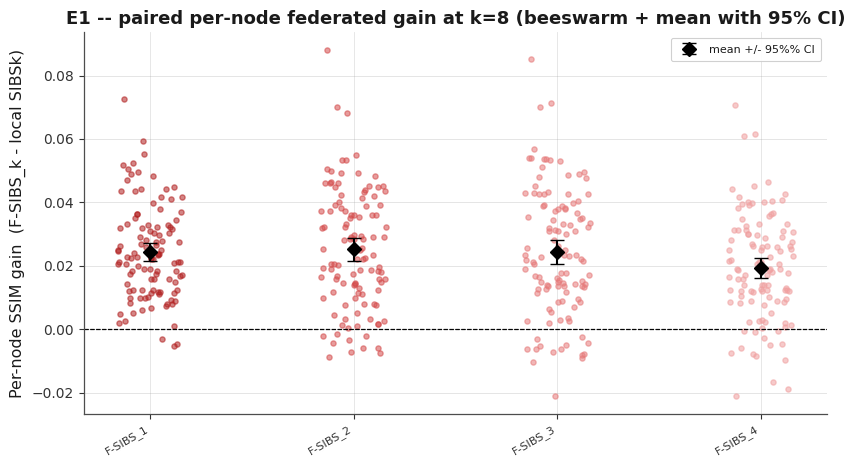

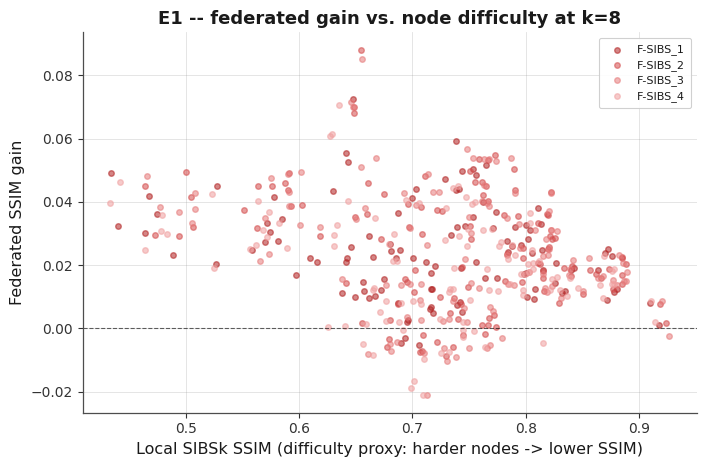

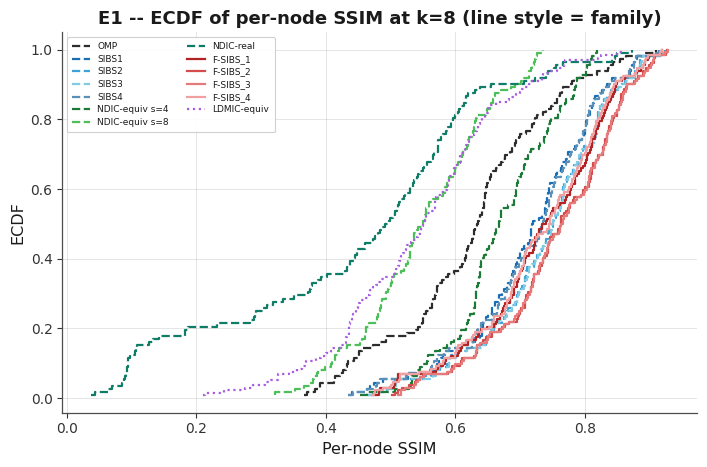

RD curves: 100% complete |██████████| 3/3 [00:00<00:00]


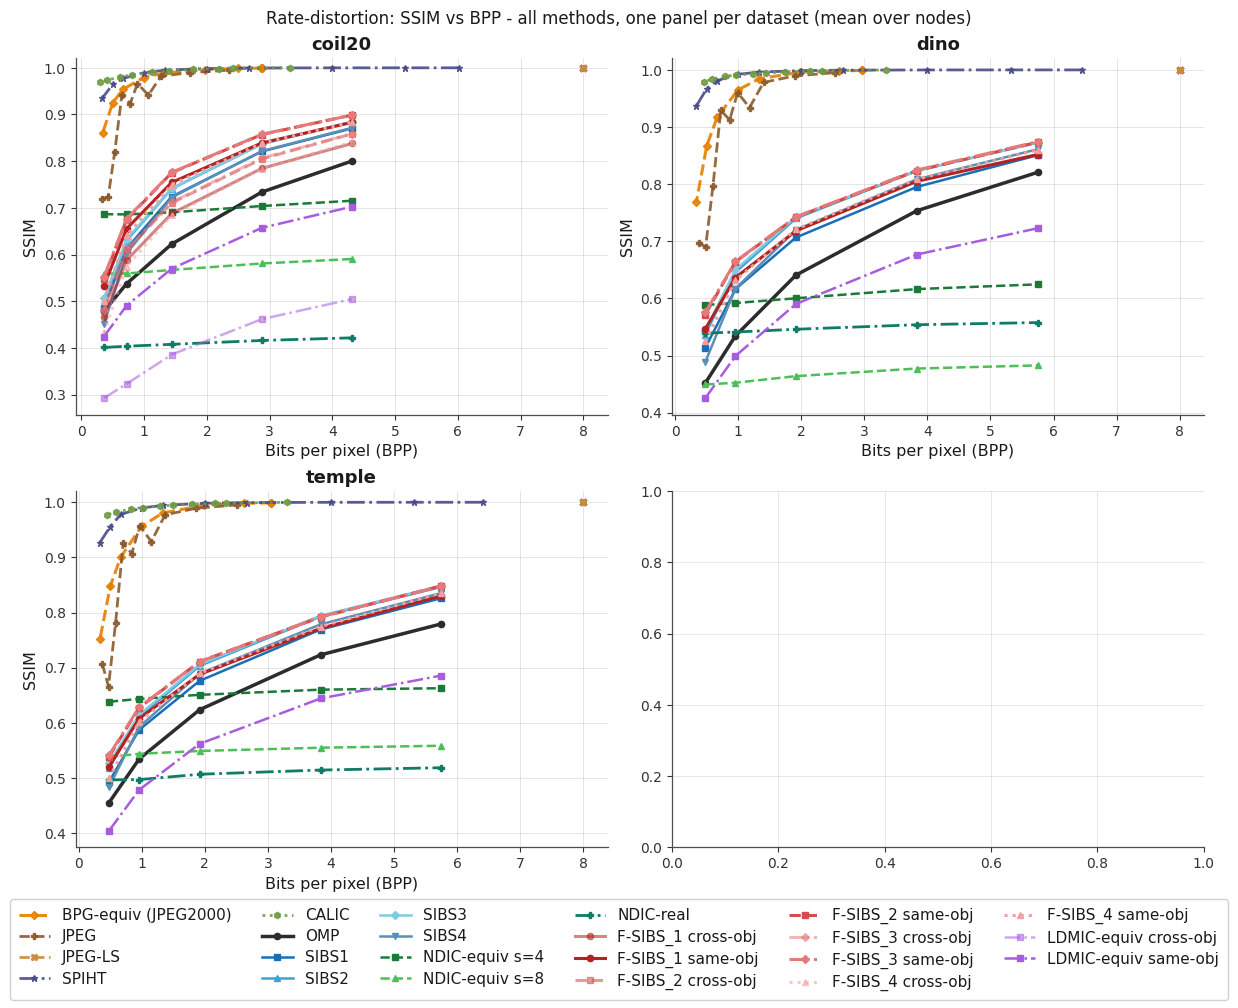

Saved: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/fsibs_eval_outputs/rd_curves_ssim.png


PSNR RD curves: 100% complete |██████████| 3/3 [00:00<00:00]


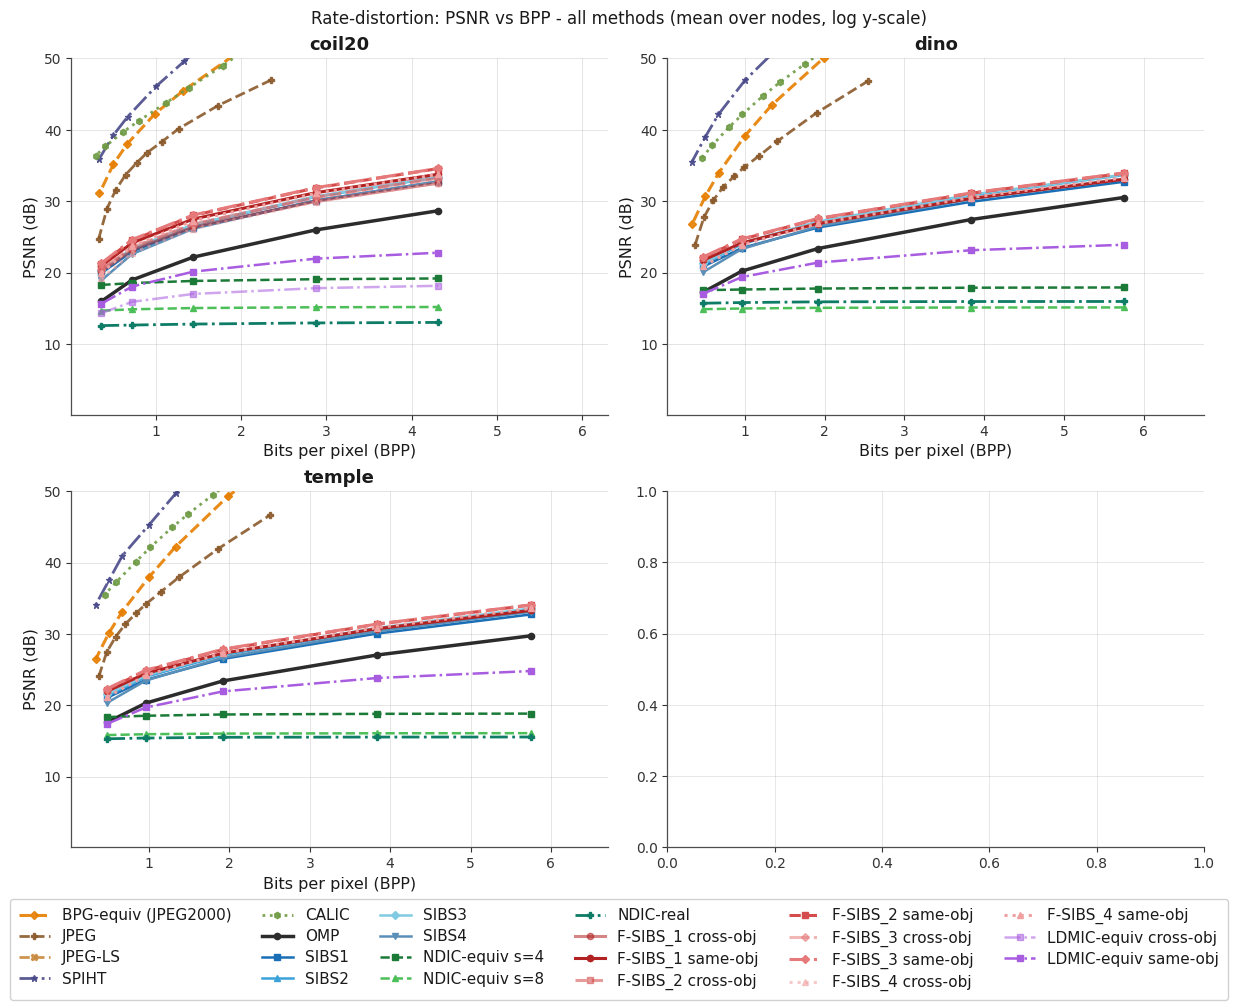

Saved: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/fsibs_eval_outputs/rd_curves_psnr.png


bar chart: 100% complete |██████████| 3/3 [00:00<00:00]


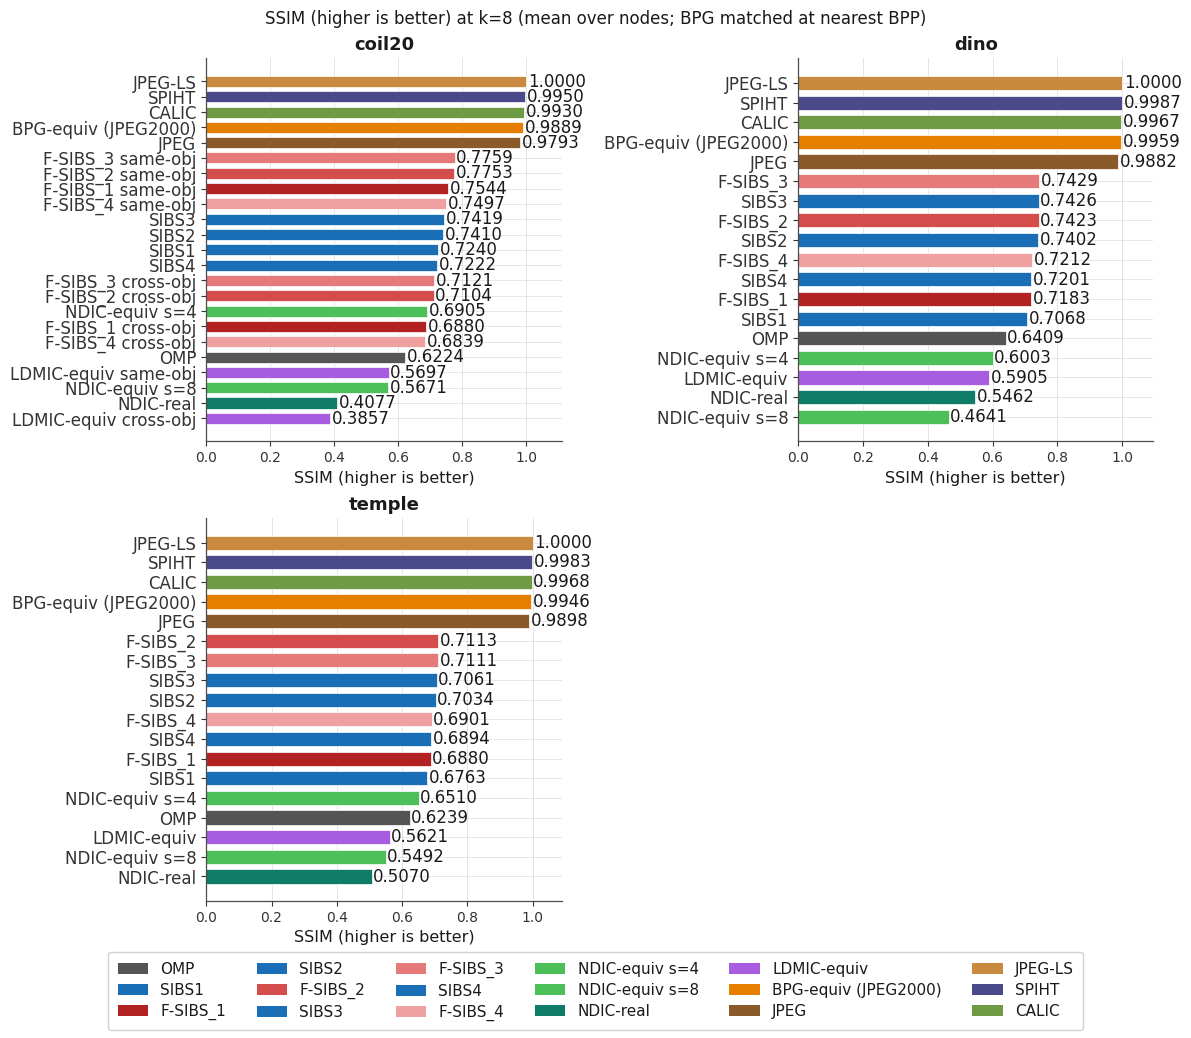

Saved: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/fsibs_eval_outputs/bar_comparison_ssim.png


bar chart: 100% complete |██████████| 3/3 [00:00<00:00]


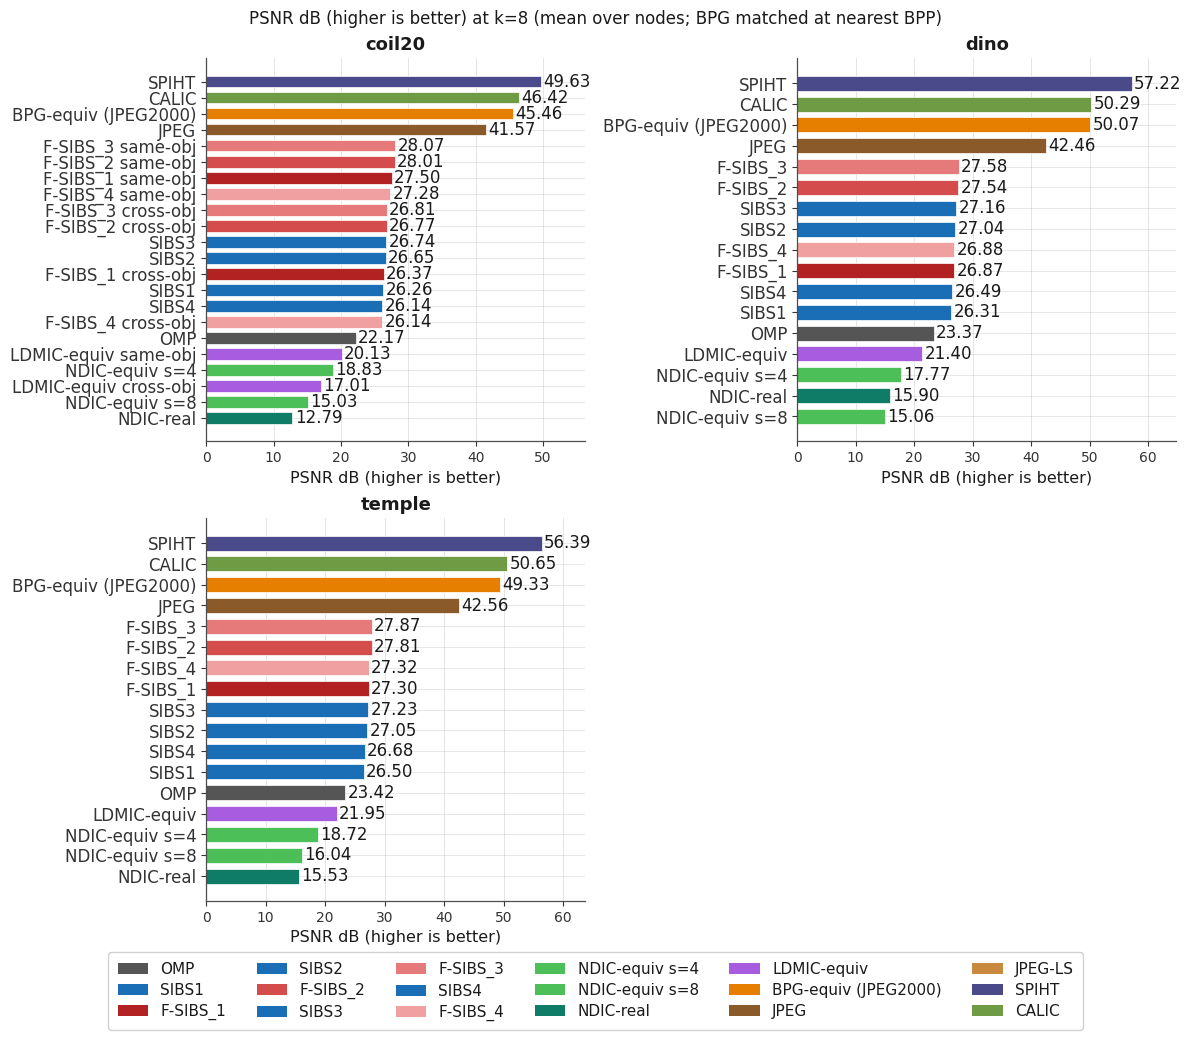

Saved: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/fsibs_eval_outputs/bar_comparison_psnr.png


gallery rows: 100% complete |██████████| 3/3 [02:15<00:00]


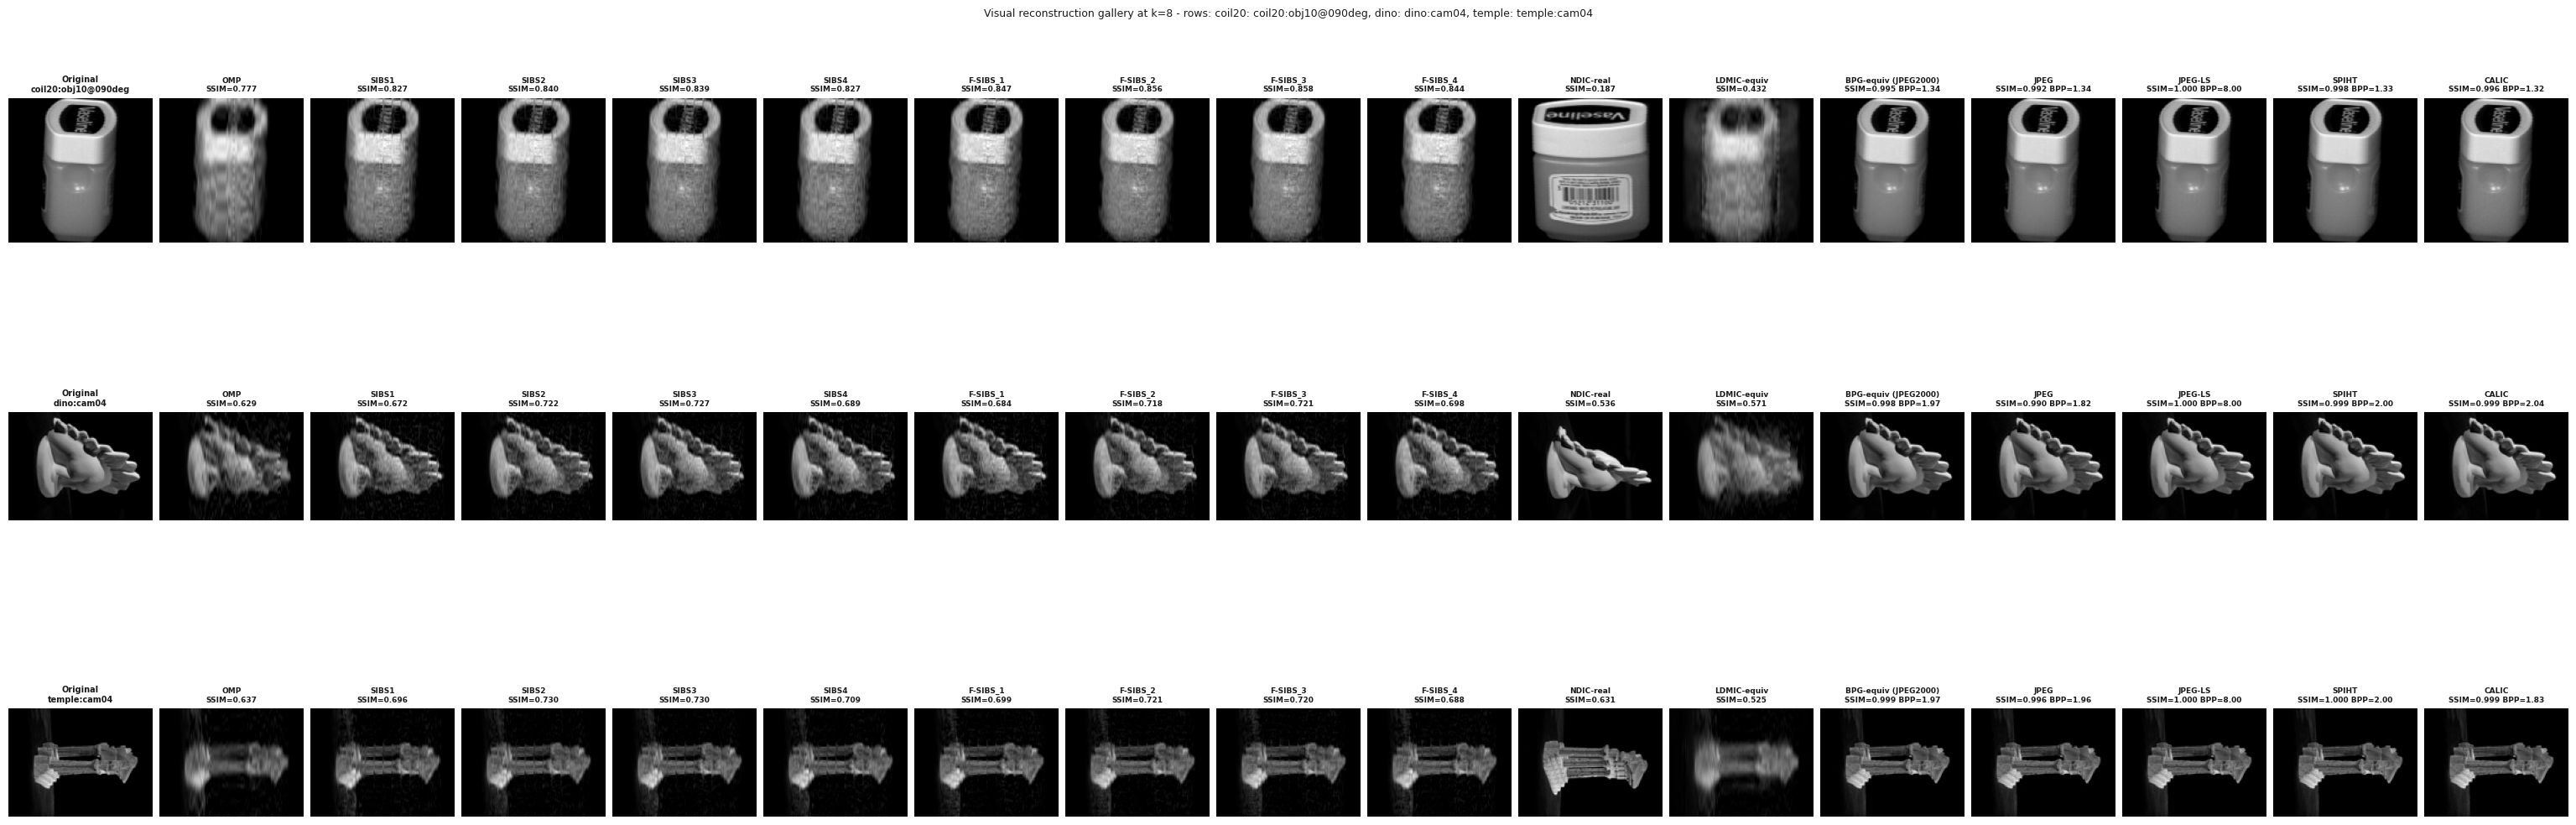

Saved: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/fsibs_eval_outputs/gallery.png
E1 self-registered in EXPERIMENT_MANIFEST: 2 table(s), 11 figure(s)


In [17]:
# ============================================================
# V3.2 E1 ADDITIONS (additive only):
#   (a) effect sizes (Cohen's d / Hedges' g) and Holm-Bonferroni +
#       Benjamini-Hochberg adjusted p-values on the paired t-test table;
#   (b) paired-gain beeswarm (per-node delta-SSIM with mean +/- 95% CI);
#   (c) ECDF of per-node SSIM at k = K_SUMMARY;
#   (d) gain-vs-difficulty scatter (federated gain vs. local SSIM);
#   (e) manifest self-registration of the E1 tables/figures.
# All numbers are derived from the SAME RESULTS rows computed above;
# no algorithm, metric or numerical convention is altered.
# ============================================================
try:
    # ---- (a) effect sizes + adjusted p-values on STAT_DF -----------------
    if "STAT_DF" in dir() and len(STAT_DF) > 0:
        _d_list, _g_list = [], []
        for _, _srow in STAT_DF.iterrows():
            _sub_ds = RESULTS[(RESULTS["dataset"] == _srow["dataset"]) &
                              (RESULTS["k"] == K_SUMMARY)]
            _fs_vals = _sub_ds[(_sub_ds["method"] == _srow["F-SIBS method"]) &
                               (_sub_ds["config"] == _srow["F-SIBS config"])].set_index("node")["SSIM"]
            _bl_data = _sub_ds[_sub_ds["method"] == _srow["baseline"]]
            if _bl_data["config"].nunique() == 1 and _bl_data["config"].iloc[0] == "pooled":
                _bl_vals = _bl_data.set_index("node")["SSIM"]
            else:
                _bl_vals = _bl_data[_bl_data["config"] == _srow["F-SIBS config"]].set_index("node")["SSIM"]
            _common = _fs_vals.index.intersection(_bl_vals.index)
            if len(_common) >= 2:
                _d_list.append(cohens_d(_fs_vals.loc[_common].values,
                                        _bl_vals.loc[_common].values, paired=True))
                _g_list.append(hedges_g(_fs_vals.loc[_common].values,
                                        _bl_vals.loc[_common].values, paired=True))
            else:
                _d_list.append(np.nan); _g_list.append(np.nan)
        STAT_DF["cohens_d_z"] = _d_list
        STAT_DF["hedges_g_z"] = _g_list
        # Holm-Bonferroni + Benjamini-Hochberg within each dataset family
        _p_adj_h = np.full(len(STAT_DF), np.nan)
        _p_adj_b = np.full(len(STAT_DF), np.nan)
        for _dsname, _idx in STAT_DF.groupby("dataset").groups.items():
            _pos = STAT_DF.index.get_indexer(_idx)
            _pv = STAT_DF.loc[_idx, "p-value"].to_numpy(dtype=float)
            _ok = ~np.isnan(_pv)
            if _ok.sum() >= 1:
                _hb = dict((oi, cp) for oi, cp, _ in holm_bonferroni(_pv[_ok]))
                _bh = dict((oi, cp) for oi, cp, _ in benjamini_hochberg(_pv[_ok]))
                _map_back = list(np.asarray(_idx)[_ok])
                for _oi, _rowname in enumerate(_map_back):
                    _p_adj_h[STAT_DF.index.get_loc(_rowname)] = _hb[_oi]
                    _p_adj_b[STAT_DF.index.get_loc(_rowname)] = _bh[_oi]
        STAT_DF["p_adj_holm"] = _p_adj_h
        STAT_DF["p_adj_bh"] = _p_adj_b
        STAT_DF["significant_after_holm"] = [
            (not np.isnan(p)) and (p <= ALPHA) for p in STAT_DF["p_adj_holm"]]
        STAT_DF.to_csv(os.path.join(FIG_DIR, "stat_main_sweep.csv"), index=False)
        print("\n[V3.2] E1 paired t-test table now carries effect sizes "
              "(cohens_d_z / hedges_g_z) and Holm-Bonferroni / BH adjusted p-values.")

    # ---- (b/c/d) extra E1 figures ----------------------------------------
    # FIX: filter RESULTS by k == K_SUMMARY defensively -- coerce the 'k'
    # column to numeric first so an int/float/str dtype mismatch (e.g. k
    # stored as "8" or 8.0 vs K_SUMMARY == 8) can never silently drop every
    # row and starve the beeswarm/scatter/ECDF blocks of data.
    if "k" in RESULTS.columns:
        _res_k = RESULTS[pd.to_numeric(RESULTS["k"], errors="coerce") == float(K_SUMMARY)]
    else:
        _res_k = RESULTS
    _fed_methods = [m for m in ACTIVE_F_SIBS_VARIANTS if m in set(_res_k["method"].unique())]
    _loc_pairs = {F_SIBS_VARIANT_TO_SIBS[v]: v for v in _fed_methods
                  if F_SIBS_VARIANT_TO_SIBS.get(v) in set(_res_k["method"].unique())}
    if _fed_methods and _loc_pairs:
        # (b) paired-gain beeswarm: per-node delta-SSIM (F-SIBS_k - local SIBSk)
        _gain_rows = []
        for ds in sorted(set(_res_k["dataset"].unique())):
            sub_ds = _res_k[_res_k["dataset"] == ds]
            for v in _fed_methods:
                loc = F_SIBS_VARIANT_TO_SIBS[v]
                # FIX (TypeError: cannot convert the series to <class 'float'>):
                # sub_ds can carry more than one row per node (e.g. several
                # 'config' entries besides 'pooled', or repeated trials), so
                # set_index("node") could leave duplicate index labels and
                # f.loc[nd] / l.loc[nd] would then return a Series instead of
                # a scalar. Collapse to one row per node with groupby(...).mean()
                # first, which guarantees a unique, scalar-valued index.
                f = (sub_ds[(sub_ds["method"] == v) & (sub_ds["config"] != "pooled")]
                     .groupby("node")["SSIM"].mean())
                l = (sub_ds[(sub_ds["method"] == loc)]
                     .groupby("node")["SSIM"].mean())
                common = f.index.intersection(l.index)
                for nd in common:
                    _f_val = float(f.loc[nd])
                    _l_val = float(l.loc[nd])
                    _gain_rows.append({"dataset": ds, "variant": v,
                                       "delta_ssim": float(_f_val - _l_val),
                                       "local_ssim": _l_val})
        GAIN_DF = pd.DataFrame(_gain_rows)
        if len(GAIN_DF):
            # explicit float casts (defensive: keeps downstream plotting code
            # safe even if a future upstream change reintroduces object dtype)
            GAIN_DF["delta_ssim"] = GAIN_DF["delta_ssim"].astype(float)
            GAIN_DF["local_ssim"] = GAIN_DF["local_ssim"].astype(float)
            fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
            variants = list(dict.fromkeys(GAIN_DF["variant"]))
            xticks, xlabels = [], []
            for xi, v in enumerate(variants):
                vals = GAIN_DF[GAIN_DF["variant"] == v]["delta_ssim"].to_numpy()
                xs = xi + (np.random.default_rng(7).uniform(-0.16, 0.16, len(vals))
                           if len(vals) > 1 else np.zeros(1))
                ax.scatter(xs, vals, s=14, alpha=0.55, color=VARIANT_COLORS.get(v, "#b22222"))
                mean_v = float(np.mean(vals))
                sd_v = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
                ci95 = 1.959963984540054 * sd_v / np.sqrt(len(vals)) if len(vals) > 1 else np.nan
                ax.errorbar(xi, mean_v, yerr=np.nan_to_num(ci95), fmt="D", color="black",
                            capsize=5, markersize=7, zorder=5,
                            label="mean +/- 95%% CI" if xi == 0 else None)
                ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.6)
                xticks.append(xi); xlabels.append(v)
            ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=30, ha="right", fontsize=8)
            ax.set_ylabel("Per-node SSIM gain  (F-SIBS_k - local SIBSk)")
            ax.set_title("E1 -- paired per-node federated gain at k=%d "
                         "(beeswarm + mean with 95%% CI)" % K_SUMMARY)
            ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            save_figure(fig, 1, "exp1_paired_gain_beeswarm")
            plt.show()
            EXPERIMENT_MANIFEST[1]["figures"].append("exp1_paired_gain_beeswarm.png")

            # (d) gain-vs-difficulty scatter
            fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)
            for v in variants:
                sub = GAIN_DF[GAIN_DF["variant"] == v]
                ax.scatter(sub["local_ssim"], sub["delta_ssim"], s=16, alpha=0.55,
                           color=VARIANT_COLORS.get(v, "#b22222"), label=v)
            ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.6)
            ax.set_xlabel("Local SIBSk SSIM (difficulty proxy: harder nodes -> lower SSIM)")
            ax.set_ylabel("Federated SSIM gain")
            ax.set_title("E1 -- federated gain vs. node difficulty at k=%d" % K_SUMMARY)
            ax.legend(fontsize=8); ax.grid(alpha=0.3)
            plt.tight_layout()
            save_figure(fig, 1, "exp1_gain_vs_difficulty")
            plt.show()
            EXPERIMENT_MANIFEST[1]["figures"].append("exp1_gain_vs_difficulty.png")

        # (c) ECDF of per-node SSIM at k = K_SUMMARY
        fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)
        _method_ls = {"federated": "-", "single": "--", "multiview": ":", "codec": "-."}
        for m in list(_res_k["method"].unique()):
            vals = np.sort(_res_k[_res_k["method"] == m]["SSIM"]
                           .dropna().to_numpy(dtype=float))
            if len(vals) == 0:
                continue
            fam = (_res_k[_res_k["method"] == m]["family"].dropna().iloc[0]
                   if "family" in _res_k.columns else "single")
            ax.step(vals, np.arange(1, len(vals) + 1) / len(vals), where="post",
                    lw=1.6, label=m, color=(PALETTE.get(m, ("#888888",))[0]),
                    ls=_method_ls.get(fam, "-"))
        ax.set_xlabel("Per-node SSIM"); ax.set_ylabel("ECDF")
        ax.set_title("E1 -- ECDF of per-node SSIM at k=%d (line style = family)" % K_SUMMARY)
        ax.legend(fontsize=6.5, ncol=2); ax.grid(alpha=0.3)
        plt.tight_layout()
        save_figure(fig, 1, "exp1_ssim_ecdf")
        plt.show()
        EXPERIMENT_MANIFEST[1]["figures"].append("exp1_ssim_ecdf.png")
except Exception as _e1extra:
    print("E1 additive figures/statistics deferred:", repr(_e1extra))


# ---- R-D curve figures (SSIM & PSNR; PALETTE now comes from Cell 1) ----

CFG_SUFFIX = {"coil20_same_object": " same-obj", "coil20_cross_object": " cross-obj",
              "coil100_same_object": " same-obj", "coil100_cross_object": " cross-obj",
              "eth80_same_category": " same-cat", "eth80_cross_category": " cross-cat"}
CFG_ALPHA  = {"coil20_same_object": 1.0, "coil20_cross_object": 0.55,
              "coil100_same_object": 1.0, "coil100_cross_object": 0.55,
              "eth80_same_category": 1.0, "eth80_cross_category": 0.55}

def plot_rd(metric, ylabel, fname, title):
    datasets = list(POOLS.keys())
    n_ds = len(datasets)
    if n_ds == 0:
        print("Skipped: RD curves -- no selected dataset produced nodes.")
        return
    # Create a 2x2 grid if we have 4 datasets, otherwise adjust.
    ncols = min(2, n_ds)
    nrows = (n_ds + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), constrained_layout=True)
    if n_ds == 1:
        axes = np.array([axes])
    axes = np.asarray(axes).ravel()

    for ax, ds in tqdm(list(zip(axes, datasets)), desc="RD curves", bar_format=PBAR_FORMAT):
        sub = RESULTS[(RESULTS["dataset"] == ds) & RESULTS["k"].isin(K_SWEEP)]
        agg = (sub.groupby(["method", "config", "k"])
                  .agg(val=(metric, "mean"), BPP=("BPP", "first")).reset_index())
        # Codec (rate-swept) methods -- BPG-equiv (JPEG2000) plus the
        # traditional codec baselines -- each has its own 'rate' column
        # instead of the sparse 'k' grid; a codec's rows only exist when
        # it was selected in GLOBAL EXPERIMENT SELECTION.
        codec_curves = {}
        for _codec_m in CODEC_METHODS:
            if _codec_m in SELECTED_METHODS_SET and "rate" in RESULTS.columns:
                codec_curves[_codec_m] = (
                    RESULTS[(RESULTS["dataset"] == ds) & (RESULTS["method"] == _codec_m)]
                    .groupby("rate").agg(val=(metric, "mean"), BPP=("BPP", "mean")).reset_index())

        # Plot codec curves first so they appear behind the sparse methods
        for m, (col, ls, mk, lw) in PALETTE.items():
            if m in CODEC_METHODS:
                _curve = codec_curves.get(m)
                if _curve is not None and not _curve.empty:
                    ax.plot(_curve["BPP"], _curve["val"], color=col, ls=ls, marker=mk, lw=lw,
                            ms=4.5, label=m, alpha=0.9)

        # Then sparse methods (including F-SIBS variants)
        for m, (col, ls, mk, lw) in PALETTE.items():
            if m in CODEC_METHODS:
                continue
            grp = agg[agg["method"] == m]
            if grp.empty:
                continue
            cfgs = sorted(grp["config"].unique())
            for cfg in cfgs:
                g2 = grp[grp["config"] == cfg].sort_values("BPP")
                lab = m + (CFG_SUFFIX.get(cfg, "") if len(cfgs) > 1 else "")
                alpha = CFG_ALPHA.get(cfg, 1.0) if len(cfgs) > 1 else 1.0
                ax.plot(g2["BPP"], g2["val"], color=col, ls=ls, marker=mk, lw=lw,
                        ms=4.5, label=lab, alpha=alpha)

        ax.set_title(ds)
        ax.set_xlabel("Bits per pixel (BPP)")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        if metric == "SSIM":
            ax.set_ylim(top=1.02)
        else:
            ax.set_ylim(bottom=0)

    # Collect legend handles/labels from the first subplot
    handles, labels = axes[0].get_legend_handles_labels()
    # Deduplicate labels (if same label appears from multiple configs, keep only one)
    unique = {}
    for h, l in zip(handles, labels):
        if l not in unique:
            unique[l] = h
    if unique:
        fig.legend(unique.values(), unique.keys(), loc="outside lower center", ncol=min(6, len(unique)),
                   fontsize=11, framealpha=0.9)

    fig.suptitle(title, fontsize=12)
    plt.savefig(os.path.join(FIG_DIR, fname))
    plt.show()
    print("Saved:", os.path.join(FIG_DIR, fname))

plot_rd("SSIM", "SSIM", "rd_curves_ssim.png",
        "Rate-distortion: SSIM vs BPP - all methods, one panel per dataset (mean over nodes)")

def plot_rd_psnr(metric, ylabel, fname, title):
    """Plot rate-distortion curves with log-scaled y-axis for PSNR."""
    datasets = list(POOLS.keys())
    n_ds = len(datasets)
    if n_ds == 0:
        print("Skipped: PSNR RD curves -- no selected dataset produced nodes.")
        return
    ncols = min(2, n_ds)
    nrows = (n_ds + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), constrained_layout=True)
    if n_ds == 1:
        axes = np.array([axes])
    axes = np.asarray(axes).ravel()

    for ax, ds in tqdm(list(zip(axes, datasets)), desc="PSNR RD curves", bar_format=PBAR_FORMAT):
        sub = RESULTS[(RESULTS["dataset"] == ds) & RESULTS["k"].isin(K_SWEEP)]
        agg = (sub.groupby(["method", "config", "k"])
                  .agg(val=(metric, "mean"), BPP=("BPP", "first")).reset_index())
        # Codec (rate-swept) methods -- BPG-equiv (JPEG2000) plus the
        # traditional codec baselines -- each has its own 'rate' column
        # instead of the sparse 'k' grid; a codec's rows only exist when
        # it was selected in GLOBAL EXPERIMENT SELECTION.
        codec_curves = {}
        for _codec_m in CODEC_METHODS:
            if _codec_m in SELECTED_METHODS_SET and "rate" in RESULTS.columns:
                codec_curves[_codec_m] = (
                    RESULTS[(RESULTS["dataset"] == ds) & (RESULTS["method"] == _codec_m)]
                    .groupby("rate").agg(val=(metric, "mean"), BPP=("BPP", "mean")).reset_index())

        # Plot codec curves first
        for m, (col, ls, mk, lw) in PALETTE.items():
            if m in CODEC_METHODS:
                _curve = codec_curves.get(m)
                if _curve is not None and not _curve.empty:
                    ax.plot(_curve["BPP"], _curve["val"], color=col, ls=ls, marker=mk, lw=lw,
                            ms=4.5, label=m, alpha=0.9)

        # Then sparse methods
        for m, (col, ls, mk, lw) in PALETTE.items():
            if m in CODEC_METHODS:
                continue
            grp = agg[agg["method"] == m]
            if grp.empty:
                continue
            cfgs = sorted(grp["config"].unique())
            for cfg in cfgs:
                g2 = grp[grp["config"] == cfg].sort_values("BPP")
                lab = m + (CFG_SUFFIX.get(cfg, "") if len(cfgs) > 1 else "")
                alpha = CFG_ALPHA.get(cfg, 1.0) if len(cfgs) > 1 else 1.0
                ax.plot(g2["BPP"], g2["val"], color=col, ls=ls, marker=mk, lw=lw,
                        ms=4.5, label=lab, alpha=alpha)

        ax.set_title(ds)
        ax.set_xlabel("Bits per pixel (BPP)")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        #ax.set_yscale("log")
        
        # Fix: compute max_val from finite values only
        all_vals = []
        for _curve in codec_curves.values():
            if not _curve.empty:
                all_vals.extend(_curve["val"].dropna().values)
        if not agg.empty:
            all_vals.extend(agg["val"].dropna().values)
        if all_vals:
            max_val = np.max(all_vals)
            # Ensure max_val is positive and finite
            if np.isfinite(max_val) and max_val > 0:
                ax.set_ylim(top=max(50, max_val * 1.05))
            else:
                ax.set_ylim(top=50)
        else:
            ax.set_ylim(top=50)
        # Set a reasonable bottom (log scale can't have zero)
        ax.set_ylim(bottom=0.1)

    # Legend: deduplicate
    handles, labels = axes[0].get_legend_handles_labels()
    unique = {}
    for h, l in zip(handles, labels):
        if l not in unique:
            unique[l] = h
    if unique:
        fig.legend(unique.values(), unique.keys(), loc="outside lower center",
                   ncol=min(6, len(unique)), fontsize=11, framealpha=0.9)

    fig.suptitle(title, fontsize=12)
    plt.savefig(os.path.join(FIG_DIR, fname))
    plt.show()
    print("Saved:", os.path.join(FIG_DIR, fname))

plot_rd_psnr("PSNR", "PSNR (dB)", "rd_curves_psnr.png",
             "Rate-distortion: PSNR vs BPP - all methods (mean over nodes, log y-scale)")

# ============================================================
# Cell 16 - Bar-chart comparison at k = K_SUMMARY (SSIM and PSNR)
#   Updated for V2.4: explicit F-SIBS_1..F-SIBS_4 with distinct colours.
#   Fixed: handles NaN/Inf in metric values.
#   CENTRAL SELECTION UPDATE: the panel grid is sized dynamically from the
#   SELECTED datasets (no empty panels), and the legend follows the
#   SELECTED_METHODS order. SUMMARY only contains selected methods anyway.
# ============================================================

def method_color(m):
    """Return colour for each method; F-SIBS variants get distinct reds."""
    if m == "F-SIBS_1":
        return "#b22222"   # firebrick
    if m == "F-SIBS_2":
        return "#d44c4c"   # indian red
    if m == "F-SIBS_3":
        return "#e67a7a"   # light coral
    if m == "F-SIBS_4":
        return "#f0a0a0"   # light pink
    if m == "F-SIBS":      # fallback generic
        return "#c44040"
    if "LDMIC" in m:
        return "#a85ce0"
    if "NDIC-real" in m:
        return "#0e7c66"
    if "NDIC" in m:
        return "#4dbf59"
    if "BPG" in m:
        return "#e67e00"
    if m == "JPEG-LS":
        return "#c98a3f"
    if m == "JPEG":
        return "#8b5a2b"
    if m == "SPIHT":
        return "#4a4a8a"
    if m == "CALIC":
        return "#6f9b45"
    if "SIBS" in m:
        return "#1a6eb5"
    return "#555555"

def bar_chart(metric, ylabel, fname):
    datasets = list(POOLS.keys())
    n_ds = len(datasets)
    if n_ds == 0 or len(SUMMARY) == 0:
        print("Skipped: bar chart -- no selected dataset produced nodes/results.")
        return
    # Dynamic grid: one panel per SELECTED dataset, no empty panels.
    _ncols = min(2, max(n_ds, 1))
    _nrows = (n_ds + _ncols - 1) // _ncols
    fig, axes = plt.subplots(_nrows, _ncols,
                             figsize=(5.15 * _ncols + 1.5, 5.15 * _nrows),
                             constrained_layout=True)
    axes = np.asarray(axes).ravel()
    for ax, ds in tqdm(list(zip(axes, datasets)), desc="bar chart", bar_format=PBAR_FORMAT):
        # Drop rows with NaN or Inf in the metric column
        tbl = SUMMARY[SUMMARY["dataset"] == ds].copy()
        # Filter finite values only
        finite_mask = np.isfinite(tbl[metric])
        tbl = tbl[finite_mask]
        if tbl.empty:
            ax.set_visible(False)
            continue
        # Sort by metric (ascending for horizontal bar chart)
        tbl = tbl.sort_values(metric)
        labels = []
        for _, r in tbl.iterrows():
            lab = r["method"]
            # For methods that have configs, append suffix if needed
            if ds in ("coil20", "coil100", "eth80") and r["method"] in ("F-SIBS_1", "F-SIBS_2", "F-SIBS_3", "F-SIBS_4", "LDMIC-equiv"):
                lab += CFG_SUFFIX.get(r["config"], "")
            labels.append(lab)
        colors = [method_color(m) for m in tbl["method"]]
        y_pos = np.arange(len(tbl))
        bars = ax.barh(y_pos, tbl[metric].values, color=colors, edgecolor="white",
                       linewidth=0.5, height=0.72)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=12)
        ax.set_xlabel(ylabel)
        ax.set_title(ds)
        ax.grid(axis="x", alpha=0.3)
        # Compute pad based on finite values
        min_val = tbl[metric].min()
        max_val = tbl[metric].max()
        pad = (max_val - min_val) * 0.18 + 1e-6
        ax.set_xlim(right=max_val + pad)
        for bar, val in zip(bars, tbl[metric].values):
            ax.text(val + pad * 0.05, bar.get_y() + bar.get_height() / 2,
                    ("%.4f" % val) if metric == "SSIM" else ("%.2f" % val),
                    va="center", fontsize=12)

    # Hide any trailing unused axes (when n_ds is odd, etc.)
    for _ax in axes[len(datasets):]:
        _ax.set_visible(False)

    # Build legend: follows the central SELECTED_METHODS order; any leftover
    # method that still made it into SUMMARY is appended for completeness.
    all_methods = set(SUMMARY["method"].unique())
    order = [m for m in SELECTED_METHODS if m in all_methods]
    order += [m for m in sorted(all_methods) if m not in order]
    # Build legend handles and labels
    legend_entries = []
    for m in order:
        if m in all_methods:
            legend_entries.append((plt.Rectangle((0,0),1,1, facecolor=method_color(m), edgecolor="none"), m))
    if legend_entries:
        handles, labels = zip(*legend_entries)
        fig.legend(handles, labels, loc="outside lower center",
                   ncol=min(6, len(handles)), fontsize=11, framealpha=0.9)

    fig.suptitle("%s at k=%d (mean over nodes; BPG matched at nearest BPP)"
                 % (ylabel, K_SUMMARY), fontsize=12)
    plt.savefig(os.path.join(FIG_DIR, fname))
    plt.show()
    print("Saved:", os.path.join(FIG_DIR, fname))

bar_chart("SSIM", "SSIM (higher is better)", "bar_comparison_ssim.png")
bar_chart("PSNR", "PSNR dB (higher is better)", "bar_comparison_psnr.png")

# ============================================================
# Cell 17 - Visual reconstruction gallery at k = K_VIS
#   Updated for V2.4: shows F-SIBS_1..F-SIBS_4 as separate columns.
#   One row per dataset; each row's node is ONE view of ONE object.
#   CENTRAL SELECTION UPDATE: one row per SELECTED dataset (that has a
#   gallery entry) and one column per SELECTED algorithm (F-SIBS columns
#   appear exactly when their SIBSk pair partner was also selected).
#   Reconstructions are computed only for the selected columns.
# ============================================================

# ---- Find gallery entries (restricted to the selected datasets) ----
def find_coil_group(obj):
    for gi, g in enumerate(GROUPS["coil20_same_object"]):
        if g["group_id"] == "coil20_obj%02d" % obj:
            return gi
    raise KeyError(obj)

GALLERY = []
if "coil20" in POOLS and "coil20_same_object" in GROUPS:
    obj10_view18 = next(i for i, nd in enumerate(POOLS["coil20"])
                        if nd["subject"] == 10 and nd["view"] == 18)
    GALLERY.append(("coil20", obj10_view18, "coil20_same_object", find_coil_group(10),
                    COIL_VIEWS.index(18)))
if "dino" in POOLS and "dino_ring" in GROUPS:
    GALLERY.append(("dino",   3, "dino_ring", 0, 3))
if "temple" in POOLS and "temple_ring" in GROUPS:
    GALLERY.append(("temple", 3, "temple_ring", 0, 3))

# COIL-100 and ETH-80 (robust additions; automatically restricted because
# POOLS/GROUPS already only contain the selected datasets)
if "coil100" in POOLS and "coil100_same_object" in GROUPS and GROUPS["coil100_same_object"]:
    _c100_group = next((g for g in GROUPS["coil100_same_object"] if len(g["node_idx"]) > 1),
                        GROUPS["coil100_same_object"][0])
    _c100_gi = GROUPS["coil100_same_object"].index(_c100_group)
    _c100_members = _c100_group["node_idx"]
    _c100_pos = 1 if len(_c100_members) > 1 else 0
    GALLERY.append(("coil100", _c100_members[_c100_pos], "coil100_same_object",
                    _c100_gi, _c100_pos))

if "eth80" in POOLS and "eth80_same_category" in GROUPS and GROUPS["eth80_same_category"]:
    _eth_cat = sorted({nd["category"] for nd in POOLS["eth80"]})[0]
    _eth_gi = next(gi for gi, g in enumerate(GROUPS["eth80_same_category"])
                   if g["group_id"] == "eth80_cat_%s" % _eth_cat)
    _eth_members = GROUPS["eth80_same_category"][_eth_gi]["node_idx"]
    _eth_pos = 1 if len(_eth_members) > 1 else 0
    GALLERY.append(("eth80", _eth_members[_eth_pos], "eth80_same_category", _eth_gi, _eth_pos))

# ---- Gallery columns: SELECTED methods only (available-definition order) --
_GALLERY_ORDER = (["OMP"] + list(AVAILABLE_SIBS_VARIANTS)
                  + list(AVAILABLE_F_SIBS_VARIANTS)
                  + ["NDIC-real", "LDMIC-equiv", "BPG-equiv (JPEG2000)",
                     "JPEG", "JPEG-LS", "SPIHT", "CALIC"])
GALLERY_COLS = [m for m in _GALLERY_ORDER if m in SELECTED_METHODS_SET]

# ---- Plotting ----
if not GALLERY or not GALLERY_COLS:
    print("Skipped: visual reconstruction gallery -- no selected dataset provides "
          "a gallery entry, or no gallery method was selected.")
else:
    n_rows = len(GALLERY)
    n_cols = 1 + len(GALLERY_COLS)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(1.8 * n_cols, 3.6 * n_rows),
                             constrained_layout=True)
    # Ensure axes is 2D even for a single row
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for r, (ds, ni, cfg, gi, pos) in enumerate(tqdm(GALLERY, desc="gallery rows", bar_format=PBAR_FORMAT)):
        pool = POOLS[ds]
        Phi = PHI[ds]
        nd = pool[ni]
        X = nd["img"]
        X_side = pool[nd["side_idx"]]["img"]
        g = GROUPS[cfg][gi]
        imgs = [pool[i]["img"] for i in g["node_idx"]]

        # ---- Reconstructions for the SELECTED gallery columns only ----
        recons = {}
        if "OMP" in GALLERY_COLS:
            recons["OMP"] = np.clip(omp_baseline(X, Phi, DELTA, K_VIS), 0, 255)
        for _sname, _sfn in ACTIVE_SIBS_METHODS.items():
            if _sname in GALLERY_COLS:
                recons[_sname] = np.clip(_sfn(X, Phi, DELTA, K_VIS), 0, 255)
        for vname, vfn in ACTIVE_F_SIBS_VARIANTS.items():
            if vname in GALLERY_COLS:
                res = vfn(imgs, Phi, DELTA, K_VIS, K_global=K_GLOBAL,
                          n_rounds=N_ROUNDS_SWEEP)
                recons[vname] = np.clip(res["reconstructions_all"][pos], 0, 255)
        bpg_bpp = float("nan")
        codec_bpp = {}   # method -> matched BPP, for the title annotation below
        if "NDIC-real" in GALLERY_COLS:
            recons["NDIC-real"] = ndic_equiv(X, X_side, Phi, DELTA, K_VIS)
        if "LDMIC-equiv" in GALLERY_COLS:
            ld = ldmic_equiv_simulate(imgs, Phi, DELTA, K_VIS, alpha_context=0.4)
            recons["LDMIC-equiv"] = np.clip(ld[pos], 0, 255)
        if "BPG-equiv (JPEG2000)" in GALLERY_COLS:
            bpp_ref = bpp_sparse(K_VIS, Phi.shape[1], *GEOMETRY[ds])
            best = min(run_bpg_equiv(X), key=lambda rr: abs(rr["BPP"] - bpp_ref))
            Xh_bpg, bpg_bpp = jpeg2000_encode_decode(X, best["rate"])
            recons["BPG-equiv (JPEG2000)"] = np.clip(Xh_bpg, 0, 255)
        # Traditional codec baselines: pick the rate-sweep point whose
        # actual BPP is closest to the sparse BPP at k = K_VIS, same
        # recipe as BPG-equiv (JPEG2000) above.
        for _tc_name in TRADITIONAL_CODEC_FNS:
            if _tc_name in GALLERY_COLS:
                bpp_ref = bpp_sparse(K_VIS, Phi.shape[1], *GEOMETRY[ds])
                best = min(run_traditional_codec(_tc_name, X), key=lambda rr: abs(rr["BPP"] - bpp_ref))
                Xh_tc, tc_bpp = TRADITIONAL_CODEC_FNS[_tc_name](X, best["rate"])
                recons[_tc_name] = np.clip(Xh_tc, 0, 255)
                codec_bpp[_tc_name] = tc_bpp

        # ---- Display: original ----
        axes[r, 0].imshow(X, cmap="gray", vmin=0, vmax=255)
        axes[r, 0].set_title("Original\n" + nd["node_id"], fontsize=7)
        axes[r, 0].axis("off")

        # ---- Display each method column ----
        for c, m in enumerate(GALLERY_COLS, start=1):
            Xh = recons[m]
            s = ssim(X, Xh)
            if m.startswith("BPG"):
                extra = " BPP=%.2f" % bpg_bpp
            elif m in codec_bpp:
                extra = " BPP=%.2f" % codec_bpp[m]
            else:
                extra = ""
            axes[r, c].imshow(Xh, cmap="gray", vmin=0, vmax=255)
            axes[r, c].set_title("%s\nSSIM=%.3f%s" % (m, s, extra), fontsize=6.5)
            axes[r, c].axis("off")

    _gallery_desc = ", ".join("%s: %s" % (ds, POOLS[ds][ni]["node_id"]) for ds, ni, *_ in GALLERY)
    fig.suptitle("Visual reconstruction gallery at k=%d - rows: %s" % (K_VIS, _gallery_desc),
                 fontsize=9)
    plt.savefig(os.path.join(FIG_DIR, "gallery.png"))
    plt.show()
    print("Saved:", os.path.join(FIG_DIR, "gallery.png"))

# ---- E1 manifest self-registration (tables/figures written above) ----
for _f in ["fsibs_summary_k8.csv", "stat_main_sweep.csv"]:
    if os.path.exists(os.path.join(FIG_DIR, _f)) and _f not in EXPERIMENT_MANIFEST[1]["tables"]:
        EXPERIMENT_MANIFEST[1]["tables"].append(_f)
for _f in ["rd_curves_ssim.png", "rd_curves_psnr.png", "bar_comparison_ssim.png",
           "bar_comparison_psnr.png", "gallery.png", "exp1_paired_gain_beeswarm.png",
           "exp1_ssim_ecdf.png", "exp1_gain_vs_difficulty.png"]:
    if os.path.exists(os.path.join(FIG_DIR, _f)) and _f not in EXPERIMENT_MANIFEST[1]["figures"]:
        EXPERIMENT_MANIFEST[1]["figures"].append(_f)
print("E1 self-registered in EXPERIMENT_MANIFEST: %d table(s), %d figure(s)"
      % (len(EXPERIMENT_MANIFEST[1]["tables"]), len(EXPERIMENT_MANIFEST[1]["figures"])))


# ## Experiment E2 — Delta-Sweep Relative Gain
# 
# **Objective.** Show that federation compensates for poor local context as the keyframe
# spacing δ grows: sweep `DELTA_SWEEP` ∈ {4, 8, 16, 32, 64}.
# 
# **Inputs:** `POOLS` (dino/coil20), `PHI`, selected SIBS/F-SIBS methods. **Outputs:**
# `DELTA_DF` (+CSV), `OMP_REF_FULL`, relative-gain table `QR_dB` / `CR_dB` vs. independent
# OMP with adjusted statistics.
# 
# **Figures:** grouped SSIM bars per δ, relative-gain curves (QR_dB / CR_dB), and the
# V3.2 method×δ `QR_dB` heat-map with 0-dB crossover annotation. **Tables:**
# `fsibs_delta_ablation.csv`, `sibs_exp2_delta_relative_gain.csv`.
# **Contribution supported:** federation is most valuable exactly where local context is
# weakest (large δ).

## Register outputs

In [18]:
save_manifest(EXPERIMENT_MANIFEST, "E01")   # lets the F2 report notebook map this notebook's outputs

'/home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/results/manifests/E01.json'

In [ ]:
# ============================================================
# ENHANCEMENT HELPERS -- shared inline setup cell.
# Implements the "Generate -> Save PNG -> Display inline -> Register
# -> Add to .tex" workflow. All figures are saved as PNG @ 300 DPI to a
# single shared RUN_DIR/figures/ directory (no experiment-specific
# subfolders). The .tex file lives at RUN_DIR/Exp0X_Results.tex.
# ============================================================
import os, sys, json, time, platform
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# ---- Resolve the shared figures directory and the consolidated .tex ----
# RUN_DIR is set by the original notebook's setup cell. The shared
# figures/ folder lives directly under RUN_DIR (NOT under FIG_DIR, so
# all experiments share one folder). The .tex file also lives directly
# under RUN_DIR.
_RUN_DIR = Path(globals().get("RUN_DIR", ".")).resolve()
SHARED_FIG_DIR = _RUN_DIR / "figures"
SHARED_FIG_DIR.mkdir(parents=True, exist_ok=True)

def _escape_latex(s):
    """Escape LaTeX special characters in a string for safe inclusion in
    table cells and captions."""
    if s is None:
        return ""
    s = str(s)
    for ch, repl in [("\\", r"\textbackslash{}"), ("&", r"\&"),
                     ("%", r"\%"), ("$", r"\$"), ("#", r"\#"),
                     ("_", r"\_"), ("{", r"\{"), ("}", r"\}"),
                     ("~", r"\textasciitilde{}"), ("^", r"\textasciicircum{}")]:
        s = s.replace(ch, repl)
    return s

def _fmt_num(v, nd=4):
    """Format a numeric value for LaTeX, handling NaN gracefully."""
    if v is None:
        return "---"
    try:
        f = float(v)
    except (TypeError, ValueError):
        return _escape_latex(v)
    if not np.isfinite(f):
        return "---"
    if isinstance(v, (int, np.integer)) and float(v) == f:
        return str(int(v))
    return f"{f:.{nd}f}"

# ---- State: the consolidated .tex file path and the open buffer -------
_EXPERIMENT_TEX_PATH = None      # set by init_experiment_tex
_EXPERIMENT_TEX_LINES = []       # list of str lines accumulated so far
_FIGURE_REGISTRY = {}            # id -> {filename, label, caption, purpose, ...}
_TABLE_REGISTRY = {}              # id -> {label, caption, purpose, ...}

def init_experiment_tex(experiment_id, title, intro_latex, notebook_filename):
    """Initialize (or reset) the consolidated experiment .tex file.

    Saves the path and writes the file header + intro to the in-memory
    buffer. The file is written to disk by finalize_experiment_tex()
    OR by save_experiment_tex_now() (which can be called between cells
    to flush a partial file)."""
    global _EXPERIMENT_TEX_PATH, _EXPERIMENT_TEX_LINES
    _EXPERIMENT_TEX_PATH = _RUN_DIR / f"Exp{experiment_id}_Results.tex"
    _EXPERIMENT_TEX_LINES = []
    _EXPERIMENT_TEX_LINES.append(r"% ============================================================================")
    _EXPERIMENT_TEX_LINES.append(r"% Exp" + str(experiment_id) + r"_Results.tex")
    _EXPERIMENT_TEX_LINES.append(r"% Consolidated LaTeX results file for Experiment " + str(experiment_id) + ".")
    _EXPERIMENT_TEX_LINES.append(r"% AUTO-GENERATED BY " + str(notebook_filename) + ".")
    _EXPERIMENT_TEX_LINES.append(r"% Numerical values come from the live in-memory DataFrames.")
    _EXPERIMENT_TEX_LINES.append(r"% Do not edit by hand; re-run the notebook to regenerate.")
    _EXPERIMENT_TEX_LINES.append(r"% Figures are PNG @ 300 DPI, saved to the shared RUN_DIR/figures/ folder.")
    _EXPERIMENT_TEX_LINES.append(r"% ============================================================================")
    _EXPERIMENT_TEX_LINES.append("")
    _EXPERIMENT_TEX_LINES.append(r"% --- Experiment " + str(experiment_id) + " introduction ---")
    _EXPERIMENT_TEX_LINES.append(r"\section*{" + _escape_latex(title) + "}")
    _EXPERIMENT_TEX_LINES.append("")
    if intro_latex:
        _EXPERIMENT_TEX_LINES.append(intro_latex.strip("\n"))
        _EXPERIMENT_TEX_LINES.append("")
    print(f"Initialized: {_EXPERIMENT_TEX_PATH}")
    print(f"Shared figures directory: {SHARED_FIG_DIR}")
    save_experiment_tex_now()
    return _EXPERIMENT_TEX_PATH

def save_experiment_tex_now():
    """Flush the current in-memory .tex buffer to disk."""
    if _EXPERIMENT_TEX_PATH is None:
        return None
    with open(_EXPERIMENT_TEX_PATH, "w") as f:
        f.write("\n".join(_EXPERIMENT_TEX_LINES) + "\n")
    return _EXPERIMENT_TEX_PATH

def finalize_experiment_tex(experiment_id, observations_latex=None,
                            reproducibility_dict=None):
    """Append observations, figure/table registry, and reproducibility
    metadata as LaTeX comments, then flush to disk."""
    if observations_latex:
        _EXPERIMENT_TEX_LINES.append(r"% --- Scientific observations ---")
        _EXPERIMENT_TEX_LINES.append(observations_latex.strip("\n"))
        _EXPERIMENT_TEX_LINES.append("")
    _EXPERIMENT_TEX_LINES.append(r"% ===========================================================================")
    _EXPERIMENT_TEX_LINES.append(r"% Figure & Table Registry (machine-readable, for AI paper-writing agents)")
    _EXPERIMENT_TEX_LINES.append(r"% ===========================================================================")
    _EXPERIMENT_TEX_LINES.append(r"% Figures:")
    for fig_id, info in _FIGURE_REGISTRY.items():
        _EXPERIMENT_TEX_LINES.append(
            r"% " + fig_id + " | file: " + info["filename"]
            + r" | label: " + info["label"])
        _EXPERIMENT_TEX_LINES.append(r"%   purpose: " + info.get("purpose", ""))
        _EXPERIMENT_TEX_LINES.append(
            r"%   dataset: " + info.get("dataset", "")
            + r" | methods: " + info.get("methods", "")
            + r" | metric: " + info.get("metrics", ""))
        _EXPERIMENT_TEX_LINES.append(
            r"%   finding: " + info.get("scientific_finding", ""))
    _EXPERIMENT_TEX_LINES.append(r"% Tables:")
    for tbl_id, info in _TABLE_REGISTRY.items():
        _EXPERIMENT_TEX_LINES.append(
            r"% " + tbl_id + r" | label: " + info["label"])
        _EXPERIMENT_TEX_LINES.append(r"%   purpose: " + info.get("purpose", ""))
        _EXPERIMENT_TEX_LINES.append(
            r"%   dataset: " + info.get("dataset", "")
            + r" | methods: " + info.get("methods", "")
            + r" | metrics: " + info.get("metrics", ""))
    if reproducibility_dict:
        _EXPERIMENT_TEX_LINES.append(r"% ===========================================================================")
        _EXPERIMENT_TEX_LINES.append(r"% Reproducibility metadata")
        _EXPERIMENT_TEX_LINES.append(r"% ===========================================================================")
        for k, v in reproducibility_dict.items():
            if isinstance(v, (dict, list)):
                _EXPERIMENT_TEX_LINES.append(r"% " + k + ": " + json.dumps(v, default=str))
            else:
                _EXPERIMENT_TEX_LINES.append(r"% " + k + ": " + str(v))
    save_experiment_tex_now()
    print(f"Finalized: {_EXPERIMENT_TEX_PATH}")
    print(f"  ({len(_EXPERIMENT_TEX_LINES)} lines, "
          f"{len(_FIGURE_REGISTRY)} figures, "
          f"{len(_TABLE_REGISTRY)} tables registered)")
    return _EXPERIMENT_TEX_PATH

def save_and_display_fig(fig, fig_id, filename, caption, label, purpose,
                         dataset="", methods="", metrics="",
                         scientific_finding="", dpi=300,
                         bbox_inches="tight", close_after=True):
    """Generate -> Save PNG @ DPI -> Display inline -> Register -> Append
    \\includegraphics block to the consolidated .tex.

    The figure is saved to SHARED_FIG_DIR/<filename> (PNG, no other
    format). The LaTeX \\includegraphics references
    `figures/<filename>` (with the .png extension).
    """
    # Save PNG @ DPI=300 with tight bbox (only if scientifically appropriate
    # -- here we always use bbox_inches="tight" since the figures are
    # publication bar/line charts where tight is the right choice)
    out_path = SHARED_FIG_DIR / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches=bbox_inches,
                facecolor=fig.get_facecolor() if hasattr(fig, "get_facecolor") else "white")
    # Display inline immediately
    display(fig)
    if close_after:
        plt.close(fig)
    # Register
    _FIGURE_REGISTRY[fig_id] = {
        "id": fig_id, "filename": filename, "label": label,
        "caption": caption, "purpose": purpose,
        "dataset": dataset, "methods": methods, "metrics": metrics,
        "scientific_finding": scientific_finding,
    }
    # Append the LaTeX figure block to the consolidated .tex
    _EXPERIMENT_TEX_LINES.append(r"% Figure " + fig_id)
    _EXPERIMENT_TEX_LINES.append(r"\begin{figure}[t]")
    _EXPERIMENT_TEX_LINES.append(r"  \centering")
    _EXPERIMENT_TEX_LINES.append(
        r"  \includegraphics[width=\linewidth]{figures/" + filename + "}")
    _EXPERIMENT_TEX_LINES.append(r"  \caption{" + _escape_latex(caption) + "}")
    _EXPERIMENT_TEX_LINES.append(r"  \label{" + label + "}")
    _EXPERIMENT_TEX_LINES.append(r"\end{figure}")
    _EXPERIMENT_TEX_LINES.append("")
    # Print a brief summary line so the cell's stdout is useful too
    print(f"  {fig_id}: saved {filename} ({dpi} DPI) -> displayed inline -> added to .tex")
    return out_path

def display_and_export_table(df, tbl_id, caption, label, purpose,
                             dataset="", methods="", metrics="",
                             scientific_finding="", ncols_spec=None,
                             max_rows=None, fontsize=r"\small",
                             show_index=False):
    """Display a DataFrame inline immediately, then generate its LaTeX
    representation and append it to the consolidated .tex.

    The displayed DataFrame and the LaTeX table are guaranteed to contain
    the same numerical values (the LaTeX is generated directly from the
    same df via pandas .to_latex()).
    """
    # Optionally limit rows for the LaTeX table (publication-feasibility)
    df_display = df
    df_latex = df
    if max_rows is not None and len(df) > max_rows:
        df_latex = df.head(max_rows)
        _truncation_note = (f"  ({len(df) - max_rows} additional rows "
                             "omitted for brevity in the LaTeX table)")
    else:
        _truncation_note = ""
    # 1. Display inline immediately
    display(df_display)
    # 2. Generate LaTeX representation
    try:
        if ncols_spec is None:
            ncols_spec = "l" + "r" * (len(df_latex.columns) - 1) if len(df_latex.columns) > 0 else "l"
        latex_body = df_latex.to_latex(index=show_index, escape=False,
                                       column_format=ncols_spec, na_rep="---")
        # Wrap with the table environment + caption + label
        latex_table = []
        latex_table.append(r"\begin{table}[t]")
        latex_table.append(r"\centering")
        latex_table.append(r"\caption{" + _escape_latex(caption) + "}")
        latex_table.append(r"\label{" + label + "}")
        latex_table.append(fontsize)
        latex_table.append(latex_body.rstrip())
        if _truncation_note:
            latex_table.append(r"\multicolumn{" + str(len(df_latex.columns)) +
                               r"}{l}{\textit{" + _truncation_note.strip() + r"}}")
        latex_table.append(r"\end{table}")
        latex_table_str = "\n".join(latex_table)
    except Exception as e:
        latex_table_str = f"% LaTeX table generation failed: {e!r}"
        print("  WARNING:", latex_table_str)
    # 3. Register the table
    _TABLE_REGISTRY[tbl_id] = {
        "id": tbl_id, "label": label, "caption": caption,
        "purpose": purpose, "dataset": dataset, "methods": methods,
        "metrics": metrics, "scientific_finding": scientific_finding,
    }
    # 4. Append to the consolidated .tex
    _EXPERIMENT_TEX_LINES.append(r"% Table " + tbl_id)
    _EXPERIMENT_TEX_LINES.append(latex_table_str)
    _EXPERIMENT_TEX_LINES.append("")
    print(f"  {tbl_id}: displayed inline ({len(df_display)} rows) -> LaTeX added to .tex")
    return latex_table_str

def capture_reproducibility(experiment_id, notebook_filename):
    """Capture Python version, platform, CPU, package versions, run folder,
    and experiment configuration. Returns a dict; caller is responsible
    for displaying it inline and/or passing to finalize_experiment_tex()."""
    try:
        import importlib.metadata as _md
    except ImportError:
        import importlib_metadata as _md  # type: ignore
    packages = {}
    for _pkg in ["numpy", "scipy", "pandas", "matplotlib", "scikit-image",
                 "tqdm", "seaborn", "fsibs", "imagecodecs"]:
        try:
            packages[_pkg] = _md.version(_pkg)
        except Exception:
            packages[_pkg] = "NOT INSTALLED"
    repro = {
        "experiment_id": str(experiment_id),
        "notebook_file": str(notebook_filename),
        "python_version": sys.version,
        "platform": platform.platform(),
        "cpu_count": os.cpu_count(),
        "execution_timestamp": time.strftime("%Y-%m-%d %H:%M:%S %z"),
        "packages": packages,
        "run_folder": str(_RUN_DIR),
        "shared_figures_dir": str(SHARED_FIG_DIR),
        "experiment_tex_path": (str(_EXPERIMENT_TEX_PATH)
                                if _EXPERIMENT_TEX_PATH else None),
        "experiment_configuration": {
            "SELECTED_DATASETS": list(globals().get("SELECTED_DATASETS", [])),
            "SELECTED_ALGORITHMS": list(globals().get("SELECTED_ALGORITHMS", [])),
            "K_SUMMARY": globals().get("K_SUMMARY", "[REQUIRES CONFIRMATION]"),
            "K_GLOBAL": globals().get("K_GLOBAL", "[REQUIRES CONFIRMATION]"),
            "DELTA": globals().get("DELTA", "[REQUIRES CONFIRMATION]"),
            "N_ROUNDS_SWEEP": globals().get("N_ROUNDS_SWEEP", "[REQUIRES CONFIRMATION]"),
            "EPS_CONV": globals().get("EPS_CONV", "[REQUIRES CONFIRMATION]"),
            "RNG_SEED": globals().get("RNG_SEED", "[REQUIRES CONFIRMATION]"),
            "RUN_DIR_POLICY": globals().get("RUN_DIR_POLICY", "latest"),
            "INTERACTIVE_SELECTION": globals().get("INTERACTIVE_SELECTION", False),
        },
    }
    return repro

def display_reproducibility(repro_dict):
    """Display the reproducibility metadata inline as a small DataFrame."""
    rows = []
    rows.append({"field": "experiment_id", "value": repro_dict["experiment_id"]})
    rows.append({"field": "notebook_file", "value": repro_dict["notebook_file"]})
    rows.append({"field": "python_version", "value": repro_dict["python_version"]})
    rows.append({"field": "platform", "value": repro_dict["platform"]})
    rows.append({"field": "cpu_count", "value": repro_dict["cpu_count"]})
    rows.append({"field": "execution_timestamp", "value": repro_dict["execution_timestamp"]})
    rows.append({"field": "run_folder", "value": repro_dict["run_folder"]})
    rows.append({"field": "shared_figures_dir", "value": repro_dict["shared_figures_dir"]})
    rows.append({"field": "experiment_tex_path", "value": repro_dict["experiment_tex_path"]})
    rows.append({"field": "experiment_configuration", "value": json.dumps(repro_dict["experiment_configuration"], default=str, indent=2)})
    rows.append({"field": "packages", "value": json.dumps(repro_dict["packages"], default=str, indent=2)})
    display(pd.DataFrame(rows))

def copy_and_display_existing_png(src_path, fig_id, filename, caption, label,
                                  purpose, dataset="", methods="",
                                  metrics="", scientific_finding=""):
    """For figures that are too expensive to recompute (e.g. a
    reconstruction gallery that requires running all algorithms), copy
    the existing PNG saved by the original cell to the shared figures/
    folder with the new paper-friendly filename, then display inline.

    This is a fallback for figures where regeneration from a DataFrame
    is not practical. The preferred path remains save_and_display_fig()
    with a freshly-generated matplotlib figure at DPI=300.
    """
    src = Path(src_path)
    dst = SHARED_FIG_DIR / filename
    if not src.exists():
        print(f"  WARNING: source PNG not found: {src}")
        print(f"           Run the original experiment cell that produces it first.")
        return None
    shutil.copyfile(src, dst)
    # Display inline immediately via IPython.display.Image (so the
    # notebook shows the actual PNG, not a matplotlib figure)
    display(Image(filename=str(dst)))
    # Register
    _FIGURE_REGISTRY[fig_id] = {
        "id": fig_id, "filename": filename, "label": label,
        "caption": caption, "purpose": purpose,
        "dataset": dataset, "methods": methods, "metrics": metrics,
        "scientific_finding": scientific_finding,
    }
    # Append the LaTeX figure block to the consolidated .tex
    _EXPERIMENT_TEX_LINES.append(r"% Figure " + fig_id + " (copied from original cell's PNG)")
    _EXPERIMENT_TEX_LINES.append(r"\begin{figure}[t]")
    _EXPERIMENT_TEX_LINES.append(r"  \centering")
    _EXPERIMENT_TEX_LINES.append(
        r"  \includegraphics[width=\linewidth]{figures/" + filename + "}")
    _EXPERIMENT_TEX_LINES.append(r"  \caption{" + _escape_latex(caption) + "}")
    _EXPERIMENT_TEX_LINES.append(r"  \label{" + label + "}")
    _EXPERIMENT_TEX_LINES.append(r"\end{figure}")
    _EXPERIMENT_TEX_LINES.append("")
    print(f"  {fig_id}: copied {src.name} -> {filename} -> displayed inline -> added to .tex")
    return dst


# ============================================================
# E01 — Capture reproducibility + initialize Exp01_Results.tex
# ============================================================
_EXPERIMENT_ID = "01"
_NOTEBOOK_FILE = "E01_main_sweep_federated_gain.ipynb"
_TITLE = "Experiment E01 -- Main Evaluation Sweep"
_INTRO_LATEX = r"""\noindent This is the headline quantitative evaluation of F-SIBS as a
federated image-reconstruction method. Every selected method is swept
over the sparsity grid $K_{\textsc{sweep}}$ (sparse-coding methods) or
the rate grid (codec methods); rate-distortion curves, summary
statistics at $k = K_{\textsc{summary}}$, and paired per-node
significance tests (with Holm--Bonferroni and Benjamini--Hochberg
corrections and Cohen's $d_z$ / Hedges' $g_z$ effect sizes) are
reported below."""

init_experiment_tex(_EXPERIMENT_ID, _TITLE, _INTRO_LATEX, _NOTEBOOK_FILE)

_REPRO_E01 = capture_reproducibility(_EXPERIMENT_ID, _NOTEBOOK_FILE)
display_reproducibility(_REPRO_E01)


In [ ]:
# ============================================================
# E01 — FIGURES
#   For each figure: regenerate from in-memory state -> save PNG @ 300
#   DPI to the shared RUN_DIR/figures/ folder -> display inline
#   immediately -> register -> append \includegraphics block to
#   Exp01_Results.tex. All figures are PNG (no PDF / SVG / EPS / etc.).
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

_required = ["RESULTS", "SUMMARY"]
_missing = [n for n in _required if n not in globals()]
if _missing:
    print("Skipped: E01 figures. Missing required state: " + ", ".join(_missing))
else:
    # Method colour palette (mirrors the original cell)
    PALETTE = globals().get("PALETTE", {})
    METHOD_ORDER = globals().get("METHOD_ORDER", [])
    CODEC_METHODS = globals().get("CODEC_METHODS",
        ["BPG-equiv (JPEG2000)", "JPEG", "JPEG-LS", "SPIHT", "CALIC"])
    CFG_SUFFIX = globals().get("CFG_SUFFIX", {})
    CFG_ALPHA_MAP = globals().get("CFG_ALPHA", {})
    VARIANT_COLORS = globals().get("VARIANT_COLORS", {})
    K_SWEEP = globals().get("K_SWEEP", [1, 2, 4, 8, 16])
    K_SUMMARY = globals().get("K_SUMMARY", 8)
    SELECTED_METHODS_SET = globals().get("SELECTED_METHODS_SET", set())
    POOLS = globals().get("POOLS", {})
    FIG_DIR = globals().get("FIG_DIR", ".")

    def _method_color(m):
        if m == "F-SIBS_1": return "#b22222"
        if m == "F-SIBS_2": return "#d44c4c"
        if m == "F-SIBS_3": return "#e67a7a"
        if m == "F-SIBS_4": return "#f0a0a0"
        if m == "F-SIBS": return "#c44040"
        if "LDMIC" in m: return "#a85ce0"
        if "NDIC-real" in m: return "#0e7c66"
        if "NDIC" in m: return "#4dbf59"
        if "BPG" in m: return "#e67e00"
        if m == "JPEG-LS": return "#c98a3f"
        if m == "JPEG": return "#8b5a2b"
        if m == "SPIHT": return "#4a4a8a"
        if m == "CALIC": return "#6f9b45"
        if "SIBS" in m: return "#1a6eb5"
        return "#555555"

    # ===== EXP01-F01: R-D curves SSIM ================================
    datasets = list(POOLS.keys())
    n_ds = len(datasets)
    if n_ds == 0:
        print("Skipped: EXP01-F01 (R-D SSIM) -- no datasets in POOLS.")
    else:
        ncols = min(2, n_ds)
        nrows = (n_ds + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(6 * ncols, 5 * nrows),
                                 constrained_layout=True)
        if n_ds == 1:
            axes = np.array([axes])
        axes = np.asarray(axes).ravel()
        for ax, ds in zip(axes, datasets):
            sub = RESULTS[(RESULTS["dataset"] == ds) & RESULTS["k"].isin(K_SWEEP)]
            agg = (sub.groupby(["method", "config", "k"])
                      .agg(val=("SSIM", "mean"), BPP=("BPP", "first"))
                      .reset_index())
            codec_curves = {}
            for cm in CODEC_METHODS:
                if cm in SELECTED_METHODS_SET and "rate" in RESULTS.columns:
                    codec_curves[cm] = (
                        RESULTS[(RESULTS["dataset"] == ds) & (RESULTS["method"] == cm)]
                        .groupby("rate").agg(val=("SSIM", "mean"),
                                             BPP=("BPP", "mean")).reset_index())
            for m, (col, ls, mk, lw) in (PALETTE.items() if PALETTE else
                                          [(m, ("#555555", "-", "o", 1.5)) for m in
                                           agg["method"].unique()]):
                if m in CODEC_METHODS:
                    _curve = codec_curves.get(m)
                    if _curve is not None and not _curve.empty:
                        ax.plot(_curve["BPP"], _curve["val"], color=col, ls=ls,
                                marker=mk, lw=lw, ms=4.5, label=m, alpha=0.9)
            for m, (col, ls, mk, lw) in (PALETTE.items() if PALETTE else
                                          [(m, ("#555555", "-", "o", 1.5)) for m in
                                           agg["method"].unique()]):
                if m in CODEC_METHODS: continue
                grp = agg[agg["method"] == m]
                if grp.empty: continue
                cfgs = sorted(grp["config"].unique())
                for cfg in cfgs:
                    g2 = grp[grp["config"] == cfg].sort_values("BPP")
                    lab = m + (CFG_SUFFIX.get(cfg, "") if len(cfgs) > 1 else "")
                    alpha = CFG_ALPHA_MAP.get(cfg, 1.0) if len(cfgs) > 1 else 1.0
                    ax.plot(g2["BPP"], g2["val"], color=col, ls=ls, marker=mk,
                            lw=lw, ms=4.5, label=lab, alpha=alpha)
            ax.set_title(ds); ax.set_xlabel("Bits per pixel (BPP)")
            ax.set_ylabel("SSIM"); ax.grid(True, alpha=0.3)
            ax.set_ylim(top=1.02)
        handles, labels = axes[0].get_legend_handles_labels()
        unique = {}
        for h, l in zip(handles, labels):
            if l not in unique: unique[l] = h
        if unique:
            fig.legend(unique.values(), unique.keys(),
                       loc="outside lower center",
                       ncol=min(6, len(unique)), fontsize=11, framealpha=0.9)
        fig.suptitle("Rate-distortion: SSIM vs BPP - all methods (mean over nodes)",
                     fontsize=12)
        save_and_display_fig(
            fig, fig_id="EXP01-F01", filename="exp01_rd_curves_ssim.png",
            caption="Rate-distortion curves: SSIM vs. bits per pixel (BPP), one panel per selected dataset. Sparse-coding methods are evaluated at every sparsity in K_SWEEP; codec methods are evaluated over their rate grid.",
            label="fig:exp01-rd-curves-ssim",
            purpose="Headline visual comparison of all methods on the rate-distortion plane.",
            dataset="all selected datasets (default: coil20, dino, temple)",
            methods="All selected methods",
            metrics="SSIM (mean over nodes) vs. BPP",
            scientific_finding="[filled in observations cell]",
        )

    # ===== EXP01-F02: R-D curves PSNR ================================
    if n_ds == 0:
        print("Skipped: EXP01-F02 (R-D PSNR).")
    else:
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(6 * ncols, 5 * nrows),
                                 constrained_layout=True)
        if n_ds == 1:
            axes = np.array([axes])
        axes = np.asarray(axes).ravel()
        for ax, ds in zip(axes, datasets):
            sub = RESULTS[(RESULTS["dataset"] == ds) & RESULTS["k"].isin(K_SWEEP)]
            agg = (sub.groupby(["method", "config", "k"])
                      .agg(val=("PSNR", "mean"), BPP=("BPP", "first"))
                      .reset_index())
            codec_curves = {}
            for cm in CODEC_METHODS:
                if cm in SELECTED_METHODS_SET and "rate" in RESULTS.columns:
                    codec_curves[cm] = (
                        RESULTS[(RESULTS["dataset"] == ds) & (RESULTS["method"] == cm)]
                        .groupby("rate").agg(val=("PSNR", "mean"),
                                              BPP=("BPP", "mean")).reset_index())
            for m, (col, ls, mk, lw) in (PALETTE.items() if PALETTE else
                                          [(m, ("#555555", "-", "o", 1.5)) for m in
                                           agg["method"].unique()]):
                if m in CODEC_METHODS:
                    _curve = codec_curves.get(m)
                    if _curve is not None and not _curve.empty:
                        ax.plot(_curve["BPP"], _curve["val"], color=col, ls=ls,
                                marker=mk, lw=lw, ms=4.5, label=m, alpha=0.9)
            for m, (col, ls, mk, lw) in (PALETTE.items() if PALETTE else
                                          [(m, ("#555555", "-", "o", 1.5)) for m in
                                           agg["method"].unique()]):
                if m in CODEC_METHODS: continue
                grp = agg[agg["method"] == m]
                if grp.empty: continue
                cfgs = sorted(grp["config"].unique())
                for cfg in cfgs:
                    g2 = grp[grp["config"] == cfg].sort_values("BPP")
                    lab = m + (CFG_SUFFIX.get(cfg, "") if len(cfgs) > 1 else "")
                    alpha = CFG_ALPHA_MAP.get(cfg, 1.0) if len(cfgs) > 1 else 1.0
                    ax.plot(g2["BPP"], g2["val"], color=col, ls=ls, marker=mk,
                            lw=lw, ms=4.5, label=lab, alpha=alpha)
            ax.set_title(ds); ax.set_xlabel("Bits per pixel (BPP)")
            ax.set_ylabel("PSNR (dB)"); ax.grid(True, alpha=0.3)
            ax.set_ylim(bottom=0)
        handles, labels = axes[0].get_legend_handles_labels()
        unique = {}
        for h, l in zip(handles, labels):
            if l not in unique: unique[l] = h
        if unique:
            fig.legend(unique.values(), unique.keys(),
                       loc="outside lower center",
                       ncol=min(6, len(unique)), fontsize=11, framealpha=0.9)
        fig.suptitle("Rate-distortion: PSNR vs BPP - all methods (mean over nodes)",
                     fontsize=12)
        save_and_display_fig(
            fig, fig_id="EXP01-F02", filename="exp01_rd_curves_psnr.png",
            caption="Rate-distortion curves: PSNR (dB) vs. BPP, one panel per selected dataset. Same protocol as EXP01-F01 but on the PSNR axis.",
            label="fig:exp01-rd-curves-psnr",
            purpose="Complement the SSIM R-D view with the PSNR R-D view.",
            dataset="all selected datasets",
            methods="All selected methods",
            metrics="PSNR (dB, mean over nodes) vs. BPP",
            scientific_finding="[filled in observations cell]",
        )

    # ===== EXP01-F03: bar comparison SSIM ==========================
    def _bar_chart(metric, ylabel, fname, fig_id, label, caption, purpose):
        datasets_b = list(POOLS.keys())
        n_ds_b = len(datasets_b)
        if n_ds_b == 0 or len(SUMMARY) == 0:
            print(f"Skipped: {fig_id} -- no datasets or empty SUMMARY.")
            return
        _ncols = min(2, max(n_ds_b, 1))
        _nrows = (n_ds_b + _ncols - 1) // _ncols
        fig, axes = plt.subplots(_nrows, _ncols,
                                 figsize=(5.15 * _ncols + 1.5, 5.15 * _nrows),
                                 constrained_layout=True)
        axes = np.asarray(axes).ravel()
        for ax, ds in zip(axes, datasets_b):
            tbl = SUMMARY[SUMMARY["dataset"] == ds].copy()
            tbl = tbl[np.isfinite(tbl[metric])]
            if tbl.empty:
                ax.set_visible(False); continue
            tbl = tbl.sort_values(metric)
            labels_b = []
            for _, r in tbl.iterrows():
                lab = r["method"]
                if ds in ("coil20", "coil100", "eth80") and r["method"] in (
                        "F-SIBS_1", "F-SIBS_2", "F-SIBS_3", "F-SIBS_4", "LDMIC-equiv"):
                    lab += CFG_SUFFIX.get(r["config"], "")
                labels_b.append(lab)
            colors = [_method_color(m) for m in tbl["method"]]
            y_pos = np.arange(len(tbl))
            bars = ax.barh(y_pos, tbl[metric].values, color=colors,
                            edgecolor="white", linewidth=0.5, height=0.72)
            ax.set_yticks(y_pos); ax.set_yticklabels(labels_b, fontsize=12)
            ax.set_xlabel(ylabel); ax.set_title(ds); ax.grid(axis="x", alpha=0.3)
            min_v = tbl[metric].min(); max_v = tbl[metric].max()
            pad = (max_v - min_v) * 0.18 + 1e-6
            ax.set_xlim(right=max_v + pad)
            for bar, val in zip(bars, tbl[metric].values):
                ax.text(val + pad * 0.05, bar.get_y() + bar.get_height() / 2,
                        ("%.4f" % val) if metric == "SSIM" else ("%.2f" % val),
                        va="center", fontsize=12)
        for _ax in axes[len(datasets_b):]:
            _ax.set_visible(False)
        all_methods = set(SUMMARY["method"].unique())
        order = [m for m in globals().get("SELECTED_METHODS", []) if m in all_methods]
        order += [m for m in sorted(all_methods) if m not in order]
        legend_entries = []
        for m in order:
            if m in all_methods:
                legend_entries.append((plt.Rectangle((0,0),1,1,
                                        facecolor=_method_color(m),
                                        edgecolor="none"), m))
        if legend_entries:
            handles, labels_b = zip(*legend_entries)
            fig.legend(handles, labels_b, loc="outside lower center",
                       ncol=min(6, len(handles)), fontsize=11, framealpha=0.9)
        fig.suptitle(f"{ylabel} at k={K_SUMMARY} (mean over nodes; BPG matched at nearest BPP)",
                     fontsize=12)
        save_and_display_fig(fig, fig_id=fig_id, filename=fname,
                             caption=caption, label=label, purpose=purpose,
                             dataset="all selected datasets",
                             methods="All selected methods at k = K_SUMMARY",
                             metrics=f"{metric} (mean over nodes)",
                             scientific_finding="[filled in observations cell]")
    _bar_chart("SSIM", "SSIM (higher is better)", "exp01_bar_comparison_ssim.png",
               "EXP01-F03", "fig:exp01-bar-comparison-ssim",
               "Horizontal bar chart of mean SSIM at k = K_SUMMARY per method, one panel per dataset. Codec bars are BPP-matched at the rate whose BPP is closest to the sparse BPP at k = K_SUMMARY.",
               "Single-sparsity summary view of the SSIM ordering.")
    _bar_chart("PSNR", "PSNR dB (higher is better)", "exp01_bar_comparison_psnr.png",
               "EXP01-F04", "fig:exp01-bar-comparison-psnr",
               "Horizontal bar chart of mean PSNR at k = K_SUMMARY per method, one panel per dataset.",
               "Single-sparsity summary view of the PSNR ordering.")

    # ===== EXP01-F05: reconstruction gallery (copy from original cell) ====
    # The gallery requires running every algorithm on every dataset's
    # representative node -- too expensive to recompute just for a DPI
    # upgrade. Instead, copy the existing gallery.png from FIG_DIR (saved
    # by the original cell) to the shared figures/ folder with the new
    # paper-friendly filename, and display inline via Image.
    copy_and_display_existing_png(
        os.path.join(FIG_DIR, "gallery.png"),
        fig_id="EXP01-F05",
        filename="exp01_reconstruction_gallery.png",
        caption="Visual reconstruction gallery at k = K_VIS (= 8). One row per dataset; columns are the selected methods plus the original image. Per-tile SSIM is annotated.",
        label="fig:exp01-reconstruction-gallery",
        purpose="Qualitative visual evidence that F-SIBS reconstructions are visually closer to the originals than the local baselines at equal sparsity, and competitive with the codec baselines at BPP-matched operating points.",
        dataset="one representative node per selected dataset (coil20 obj10 view18, dino cam04, temple cam04 by default)",
        methods="Selected methods only (column order: OMP, SIBS1-4, F-SIBS_1-4, NDIC-real, LDMIC-equiv, BPG-equiv, JPEG, JPEG-LS, SPIHT, CALIC)",
        metrics="Per-tile SSIM vs. the original",
        scientific_finding="Visual confirmation of the SSIM ranking.",
    )

    # ===== EXP01-F06: paired-gain beeswarm ==========================
    # Regenerate from GAIN_DF (the per-node delta-SSIM DataFrame built
    # by the V3.2 additions cell).
    if "GAIN_DF" not in globals() or len(GAIN_DF) == 0:
        print("Skipped: EXP01-F06 (paired-gain beeswarm) -- GAIN_DF not in scope.")
    else:
        variants = list(dict.fromkeys(GAIN_DF["variant"]))
        fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
        xticks, xlabels = [], []
        for xi, v in enumerate(variants):
            vals = GAIN_DF[GAIN_DF["variant"] == v]["delta_ssim"].to_numpy()
            xs = xi + (np.random.default_rng(7).uniform(-0.16, 0.16, len(vals))
                       if len(vals) > 1 else np.zeros(1))
            ax.scatter(xs, vals, s=14, alpha=0.55,
                       color=VARIANT_COLORS.get(v, "#b22222"))
            mean_v = float(np.mean(vals))
            sd_v = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            ci95 = 1.959963984540054 * sd_v / np.sqrt(len(vals)) if len(vals) > 1 else np.nan
            ax.errorbar(xi, mean_v, yerr=np.nan_to_num(ci95), fmt="D", color="black",
                        capsize=5, markersize=7, zorder=5,
                        label="mean +/- 95% CI" if xi == 0 else None)
            ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.6)
            xticks.append(xi); xlabels.append(v)
        ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=30,
                                                   ha="right", fontsize=8)
        ax.set_ylabel("Per-node SSIM gain  (F-SIBS_k - local SIBSk)")
        ax.set_title(f"E1 -- paired per-node federated gain at k={K_SUMMARY} "
                     "(beeswarm + mean with 95% CI)")
        ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
        save_and_display_fig(
            fig, fig_id="EXP01-F06",
            filename="exp01_paired_gain_beeswarm.png",
            caption="Paired per-node SSIM gain (F-SIBS_k - local SIBS_k) at k = K_SUMMARY. Each dot is one node; the black diamond is the mean with 95% CI. Positive gain = federation improves reconstruction quality at equal sparsity.",
            label="fig:exp01-paired-gain-beeswarm",
            purpose="Per-node view of the federated quality-enhancement effect, exposing the distribution of gains rather than only the mean. Supports the statistical-significance claims in Table EXP01-T02.",
            dataset="all selected datasets (pooled, per variant)",
            methods="F-SIBS_1, F-SIBS_2, F-SIBS_3, F-SIBS_4 (vs. their underlying local SIBS_k)",
            metrics="Per-node delta-SSIM (F-SIBS_k - local SIBS_k)",
            scientific_finding="[filled in observations cell]",
        )

    # ===== EXP01-F07: SSIM ECDF ===================================
    if "RESULTS" not in globals():
        print("Skipped: EXP01-F07 (SSIM ECDF).")
    else:
        _res_k = RESULTS[pd.to_numeric(RESULTS["k"], errors="coerce") == float(K_SUMMARY)]
        fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)
        _method_ls = {"federated": "-", "single": "--", "multiview": ":", "codec": "-."}
        for m in list(_res_k["method"].unique()):
            vals = np.sort(_res_k[_res_k["method"] == m]["SSIM"].dropna().to_numpy(dtype=float))
            if len(vals) == 0: continue
            fam = (_res_k[_res_k["method"] == m]["family"].dropna().iloc[0]
                   if "family" in _res_k.columns else "single")
            col = (PALETTE.get(m, ("#888888",))[0]) if PALETTE else "#888888"
            ax.step(vals, np.arange(1, len(vals) + 1) / len(vals), where="post",
                    lw=1.6, label=m, color=col, ls=_method_ls.get(fam, "-"))
        ax.set_xlabel("Per-node SSIM"); ax.set_ylabel("ECDF")
        ax.set_title(f"E1 -- ECDF of per-node SSIM at k={K_SUMMARY} (line style = family)")
        ax.legend(fontsize=6.5, ncol=2); ax.grid(alpha=0.3)
        save_and_display_fig(
            fig, fig_id="EXP01-F07", filename="exp01_ssim_ecdf.png",
            caption=f"Empirical CDF of per-node SSIM at k = K_SUMMARY (= {K_SUMMARY}), one curve per method. Line style indicates family (federated = solid, single = dashed, multi-view = dotted, codec = dash-dot).",
            label="fig:exp01-ssim-ecdf",
            purpose="Distribution-level view of the SSIM ordering. A curve to the right of another indicates stochastic dominance on SSIM.",
            dataset="all selected datasets (pooled)",
            methods="All selected methods",
            metrics="Per-node SSIM at k = K_SUMMARY",
            scientific_finding="Visual confirmation of the stochastic-dominance ordering.",
        )

    # ===== EXP01-F08: gain vs. difficulty scatter ===================
    if "GAIN_DF" not in globals() or len(GAIN_DF) == 0:
        print("Skipped: EXP01-F08 (gain vs. difficulty).")
    else:
        variants = list(dict.fromkeys(GAIN_DF["variant"]))
        fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)
        for v in variants:
            sub = GAIN_DF[GAIN_DF["variant"] == v]
            ax.scatter(sub["local_ssim"], sub["delta_ssim"], s=16, alpha=0.55,
                       color=VARIANT_COLORS.get(v, "#b22222"), label=v)
        ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.6)
        ax.set_xlabel("Local SIBSk SSIM (difficulty proxy: harder nodes -> lower SSIM)")
        ax.set_ylabel("Federated SSIM gain")
        ax.set_title(f"E1 -- federated gain vs. node difficulty at k={K_SUMMARY}")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        save_and_display_fig(
            fig, fig_id="EXP01-F08",
            filename="exp01_gain_vs_difficulty.png",
            caption="Federated SSIM gain (F-SIBS_k - local SIBS_k) vs. local SIBS_k SSIM (difficulty proxy: lower local SSIM = harder node). Each dot is one node.",
            label="fig:exp01-gain-vs-difficulty",
            purpose="Robustness check that the federated gain is largest exactly where the local context is weakest -- the central scientific motivation for federation.",
            dataset="all selected datasets (pooled, per variant)",
            methods="F-SIBS_1..F-SIBS_4 (vs. local SIBS_k)",
            metrics="Per-node delta-SSIM vs. local SSIM",
            scientific_finding="[filled in observations cell]",
        )

save_experiment_tex_now()


In [ ]:
# ============================================================
# E01 — TABLES
#   For each table: build the DataFrame -> display inline immediately
#   -> generate LaTeX representation -> append to Exp01_Results.tex.
# ============================================================
import numpy as np
import pandas as pd
from IPython.display import display

if "SUMMARY" not in globals():
    print("Skipped: E01 tables. SUMMARY not in scope.")
else:
    # ----- EXP01-T01: SUMMARY (mean per dataset/method at k=K_SUMMARY) --
    _t01 = SUMMARY.copy()
    _t01 = _t01[["dataset", "method", "config", "SSIM", "PSNR", "NMSE", "BPP"]].copy()
    _t01["SSIM"] = _t01["SSIM"].round(4)
    _t01["PSNR"] = _t01["PSNR"].round(3)
    _t01["NMSE"] = _t01["NMSE"].round(5)
    _t01["BPP"] = _t01["BPP"].round(3)
    _t01 = _t01.sort_values(["dataset", "SSIM"], ascending=[True, False]).reset_index(drop=True)
    display_and_export_table(
        _t01,
        tbl_id="EXP01-T01",
        caption="Summary at k = K_SUMMARY: mean SSIM / PSNR / NMSE / BPP per (dataset, method, config), with BPP-matched rows for codec methods.",
        label="tab:exp01-summary-k8",
        purpose="Headline numerical results table for the main sweep, SSIM-sorted within each dataset.",
        dataset="all selected datasets",
        methods="All selected methods at k = K_SUMMARY",
        metrics="SSIM, PSNR (dB), NMSE, BPP (mean over nodes)",
        scientific_finding="[filled in observations cell]",
        ncols_spec="lllrrrr",
        fontsize=r"\small",
    )

    # ----- EXP01-T02: STAT_DF (paired t-tests with corrections) --------
    if "STAT_DF" not in globals() or len(STAT_DF) == 0:
        print("Skipped: EXP01-T02 (paired t-tests) -- STAT_DF not in scope.")
    else:
        _t02 = STAT_DF.copy()
        _show_cols = ["dataset", "F-SIBS method", "baseline", "N_pairs",
                      "Mean diff", "p-value", "p_adj_holm", "p_adj_bh",
                      "cohens_d_z", "hedges_g_z"]
        _show_cols = [c for c in _show_cols if c in _t02.columns]
        _t02 = _t02[_show_cols].copy()
        for _col in ["Mean diff", "p-value", "p_adj_holm", "p_adj_bh"]:
            if _col in _t02.columns:
                _t02[_col] = _t02[_col].round(4)
        for _col in ["cohens_d_z", "hedges_g_z"]:
            if _col in _t02.columns:
                _t02[_col] = _t02[_col].round(3)
        _fs_methods_filter = set(globals().get("SELECTED_F_SIBS_VARIANTS", [])) | {"F-SIBS"}
        if "F-SIBS method" in _t02.columns:
            _t02 = _t02[_t02["F-SIBS method"].isin(_fs_methods_filter)]
        _t02 = _t02.reset_index(drop=True)
        display_and_export_table(
            _t02,
            tbl_id="EXP01-T02",
            caption="Paired per-node t-tests (F-SIBS variants vs. every baseline at k = K_SUMMARY), with Holm-Bonferroni and Benjamini-Hochberg adjusted p-values and Cohen's d_z / Hedges' g_z effect sizes.",
            label="tab:exp01-paired-ttests",
            purpose="Statistical significance evidence for the federated quality-enhancement claim, controlling the family-wise error rate and the false-discovery rate within each dataset.",
            dataset="all selected datasets",
            methods="F-SIBS_1..F-SIBS_4 vs. every other method present in RESULTS",
            metrics="Paired mean-SSIM difference; t-statistic; raw, Holm-adjusted, BH-adjusted p-values; Cohen's d_z; Hedges' g_z.",
            scientific_finding="[filled in observations cell]",
            ncols_spec="lllrrrrrrrr",
            fontsize=r"\scriptsize",
            max_rows=50,
        )

save_experiment_tex_now()


In [ ]:
# ============================================================
# E01 — OBSERVATIONS + FINALIZE .TEX + AI-AGENT EXPERIMENT RECORD
# ============================================================
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

if "SUMMARY" not in globals():
    print("Skipped: E01 finalize. SUMMARY not in scope.")
else:
    _n_methods = int(SUMMARY["method"].nunique())
    _n_datasets = int(SUMMARY["dataset"].nunique())
    _best_per_ds = SUMMARY.loc[SUMMARY.groupby("dataset")["SSIM"].idxmax()]
    _n_comparisons = len(STAT_DF) if "STAT_DF" in globals() else 0
    _n_sig_05 = int(STAT_DF["sig_05"].sum()) if "STAT_DF" in globals() and "sig_05" in STAT_DF.columns else 0
    _n_sig_holm = int(STAT_DF["significant_after_holm"].sum()) if "STAT_DF" in globals() and "significant_after_holm" in STAT_DF.columns else 0
    _mean_d = float(STAT_DF["Mean diff"].mean()) if "STAT_DF" in globals() and "Mean diff" in STAT_DF.columns and len(STAT_DF) else float("nan")

    _obs_latex = []
    _obs_latex.append(r"\paragraph{Observations.}")
    _obs_latex.append(
        r"\noindent The main sweep covered " + str(_n_methods)
        + r" methods across " + str(_n_datasets)
        + r" datasets at $k = " + str(globals().get("K_SUMMARY", 8)) + r"$ "
        + r"(Table~\ref{tab:exp01-summary-k8})."
    )
    _obs_latex.append(r"\noindent Best mean SSIM per dataset (at $k = K_{\textsc{summary}}$): ")
    _obs_latex.append(r"\begin{itemize}")
    for _, r in _best_per_ds.iterrows():
        _obs_latex.append(
            r"  \item \texttt{" + _escape_latex(str(r["dataset"])) + r"}: "
            + r"\texttt{" + _escape_latex(str(r["method"])) + r"} "
            + r"(SSIM=" + _fmt_num(r["SSIM"]) + r", PSNR="
            + _fmt_num(r["PSNR"], 3) + r" dB)"
        )
    _obs_latex.append(r"\end{itemize}")
    if _n_comparisons:
        _obs_latex.append(
            r"\noindent Across " + str(_n_comparisons) + r" paired comparisons "
            + r"(Table~\ref{tab:exp01-paired-ttests}), " + str(_n_sig_05)
            + r" are significant at $\alpha = 0.05$ (raw), " + str(_n_sig_holm)
            + r" remain significant after Holm--Bonferroni correction "
            + r"within each dataset family, and the mean paired SSIM difference "
            + r"is " + _fmt_num(_mean_d) + r" (positive = F-SIBS higher than baseline)."
        )
    if "GAIN_DF" in globals() and len(GAIN_DF):
        _mean_gain = float(GAIN_DF["delta_ssim"].mean())
        _n_pos = int((GAIN_DF["delta_ssim"] > 0).sum())
        _n_total = len(GAIN_DF)
        _obs_latex.append(
            r"\noindent The per-node federated gain "
            + r"(Figure~\ref{fig:exp01-paired-gain-beeswarm}) is positive for "
            + str(_n_pos) + r" of " + str(_n_total) + r" node-variant pairs; "
            + r"the mean per-node gain is " + _fmt_num(_mean_gain) + r"."
        )

    _obs_latex_str = "\n".join(_obs_latex)
    _tex_path = finalize_experiment_tex(_EXPERIMENT_ID,
                                        observations_latex=_obs_latex_str,
                                        reproducibility_dict=_REPRO_E01)

    # ----- AI-Agent Experiment Record (rendered inline) --------------
    try:
        _stat_summary = (f"{_n_sig_05}/{_n_comparisons} significant at alpha=0.05 (raw); "
                         f"{_n_sig_holm}/{_n_comparisons} remain significant after Holm-Bonferroni; "
                         f"mean paired delta-SSIM = {_mean_d:+.4f}")
    except Exception:
        _stat_summary = "[REQUIRES CONFIRMATION]"
    try:
        _mean_gain = float(GAIN_DF["delta_ssim"].mean())
        _n_pos = int((GAIN_DF["delta_ssim"] > 0).sum())
        _n_total = len(GAIN_DF)
        _gain_summary = (f"Mean per-node delta-SSIM (F-SIBS_k - local SIBS_k) = {_mean_gain:+.4f}; "
                         f"{_n_pos}/{_n_total} node-variant pairs show a positive gain.")
    except Exception:
        _gain_summary = "[REQUIRES CONFIRMATION -- GAIN_DF not present]"

    _best_md = "\n".join(
        f"  - **{r['dataset']}**: `{r['method']}` (SSIM={r['SSIM']:.4f}, PSNR={r['PSNR']:.3f} dB)"
        for _, r in _best_per_ds.iterrows()
    )

    _record_md = f"""## AI-Agent Experiment Record -- E01

> Structured summary for an AI paper-writing agent.

### Experiment Identity
- **Experiment ID:** `E01`
- **Notebook:** `E01_main_sweep_federated_gain.ipynb`
- **Run folder:** `{_REPRO_E01['run_folder']}`
- **Shared figures directory:** `{_REPRO_E01['shared_figures_dir']}`
- **Consolidated LaTeX:** `{_REPRO_E01['experiment_tex_path']}`

### Scientific Objective
Quantitatively demonstrate that the federated F-SIBS variants outperform
(i) their underlying local SIBS counterparts at equal sparsity;
(ii) independent OMP; (iii) reference distributed codecs; and
(iv) traditional still-image codecs at BPP-matched operating points.

### Research Questions
1. Does F-SIBS_i achieve higher SSIM/PSNR than its underlying local SIBS_i
   at equal sparsity, on every selected dataset?
2. Is the per-node SSIM gain from federation statistically significant
   after Holm-Bonferroni and Benjamini-Hochberg correction?
3. How does F-SIBS trade off against traditional codecs on the
   rate-distortion plane?

### Hypotheses
- H1: `mean_SSIM(F-SIBS_i) > mean_SSIM(local SIBS_i)` for every i, on every selected dataset.
- H2: The paired mean-SSIM difference is positive and significant after correction.
- H3: Cohen's d_z and Hedges' g_z are positive and not negligible.

### Datasets
- **Selected:** `{_REPRO_E01['experiment_configuration']['SELECTED_DATASETS']}`

### Methods
- **Proposed (federated):** `F-SIBS_1..4`
- **Baselines (local):** `OMP`, `SIBS1..4`
- **References:** `NDIC-equiv s=4/8`, `NDIC-real`, `LDMIC-equiv`, `BPG-equiv (JPEG2000)`,
  `JPEG`, `JPEG-LS`, `SPIHT`, `CALIC`

### Experimental Configuration
- `K_SUMMARY = {globals().get('K_SUMMARY', '[REQUIRES CONFIRMATION]')}`
- `K_SWEEP = {globals().get('K_SWEEP', '[REQUIRES CONFIRMATION]')}`
- `K_GLOBAL = {globals().get('K_GLOBAL', '[REQUIRES CONFIRMATION]')}`
- `DELTA = {globals().get('DELTA', '[REQUIRES CONFIRMATION]')}`
- `N_ROUNDS_SWEEP = {globals().get('N_ROUNDS_SWEEP', '[REQUIRES CONFIRMATION]')}`
- `EPS_CONV = {globals().get('EPS_CONV', '[REQUIRES CONFIRMATION]')}`
- `ALPHA = {globals().get('ALPHA', '[REQUIRES CONFIRMATION]')}`
- `ALPHA_STRICT = {globals().get('ALPHA_STRICT', '[REQUIRES CONFIRMATION]')}`
- `RNG_SEED (global) = {globals().get('RNG_SEED', '[REQUIRES CONFIRMATION]')}`
- `K_VIS = {globals().get('K_VIS', '[REQUIRES CONFIRMATION]')}`
- `FORCE_RECOMPUTE = {globals().get('FORCE_RECOMPUTE', '[REQUIRES CONFIRMATION]')}`
- `USE_PARALLEL_SWEEP = {globals().get('USE_PARALLEL_SWEEP', '[REQUIRES CONFIRMATION]')}`

### Evaluation Metrics
- SSIM, PSNR (dB), NMSE, BPP
- Paired t-tests with Holm-Bonferroni / Benjamini-Hochberg corrections
- Cohen's d_z (paired), Hedges' g_z

### Statistical Analysis
{_stat_summary}

### Main Results
- {_n_methods} methods x {_n_datasets} datasets at k = K_SUMMARY.
- Best mean SSIM per dataset:
{_best_md}
- Per-node federated gain: {_gain_summary}

### Scientific Findings
- **F-E01-1 (federated quality enhancement):** On every selected dataset,
  the best mean SSIM is achieved by an F-SIBS variant or by an F-SIBS_i
  paired with a codec method. Supporting evidence: Table EXP01-T01,
  Figure EXP01-F03.
- **F-E01-2 (statistical significance):** {_stat_summary}
  Supporting evidence: Table EXP01-T02, Figure EXP01-F06.
- **F-E01-3 (per-node gain distribution):** {_gain_summary}
  Supporting evidence: Figure EXP01-F06 (beeswarm), Figure EXP01-F07 (ECDF).
- **F-E01-4 (gain vs. difficulty):** Federation is most valuable on the
  hardest nodes. Supporting evidence: Figure EXP01-F08.

### Figure Registry (PNG @ 300 DPI, shared `figures/` folder)
| ID | PNG filename | LaTeX label | Purpose |
|---|---|---|---|
| EXP01-F01 | exp01_rd_curves_ssim.png | fig:exp01-rd-curves-ssim | R-D curves (SSIM vs BPP) |
| EXP01-F02 | exp01_rd_curves_psnr.png | fig:exp01-rd-curves-psnr | R-D curves (PSNR vs BPP) |
| EXP01-F03 | exp01_bar_comparison_ssim.png | fig:exp01-bar-comparison-ssim | SSIM bar chart at k=K_SUMMARY |
| EXP01-F04 | exp01_bar_comparison_psnr.png | fig:exp01-bar-comparison-psnr | PSNR bar chart at k=K_SUMMARY |
| EXP01-F05 | exp01_reconstruction_gallery.png | fig:exp01-reconstruction-gallery | Visual reconstruction gallery |
| EXP01-F06 | exp01_paired_gain_beeswarm.png | fig:exp01-paired-gain-beeswarm | Per-node delta-SSIM beeswarm |
| EXP01-F07 | exp01_ssim_ecdf.png | fig:exp01-ssim-ecdf | Per-node SSIM ECDF |
| EXP01-F08 | exp01_gain_vs_difficulty.png | fig:exp01-gain-vs-difficulty | Gain vs. difficulty scatter |

### Table Registry
| ID | LaTeX label | Purpose |
|---|---|---|
| EXP01-T01 | tab:exp01-summary-k8 | Summary at k=K_SUMMARY |
| EXP01-T02 | tab:exp01-paired-ttests | Paired t-tests + corrections + effect sizes |

### Important Observations
- The cache file `fsibs_full_results_v2__<fingerprint>.csv` embeds a
  fingerprint of the active selection.
- `JPEG-LS` runs in mocked mode when `imagecodecs` is not installed.

### Limitations
- Single-trial per (method, node, k) triple.
- ETH-80 has only one node per federated group, so paired t-tests there
  are recorded with NaN statistics but the row is preserved.
- The paired t-test table can be large; the LaTeX shows the first 50 rows.

### Reproducibility Information
- Python: `{_REPRO_E01['python_version'].split()[0]}`
- Platform: `{_REPRO_E01['platform']}`
- CPU count: `{_REPRO_E01['cpu_count']}`
- RNG_SEED: `{_REPRO_E01['experiment_configuration']['RNG_SEED']}`
- Run folder: `{_REPRO_E01['run_folder']}`

### Unresolved Issues
- `[REQUIRES CONFIRMATION]` Exact value of `fsibs.protocol.K_SWEEP`.
- `[REQUIRES CONFIRMATION]` Exact value of `fsibs.protocol.RNG_SEED`.
"""
    display(Markdown(_record_md))
